# When Graph AI Is Not Enough: Temporal and Cross-Benchmark Evidence from Cryptocurrency AML Detection

**Target framing:** a deployment-realistic RegTech benchmark of graph AI, graph features, graph embeddings, neural models, and tree ensembles for cryptocurrency anti-money-laundering detection.

## Research Questions and Hypotheses

**RQ1.** Do graph-based learning models outperform tabular machine-learning models for illicit Bitcoin transaction detection?

**RQ2.** How much does performance change when evaluation is temporal rather than random?

**RQ3.** Which transaction features and graph neighborhoods explain high-risk AML predictions?

**Hypotheses**

- **H1:** Graph-aware models improve illicit transaction detection compared with transaction-feature-only baselines.
- **H2:** Temporal evaluation produces lower but more realistic performance than random evaluation.
- **H3:** Graph-aware models improve recall at high precision, a practical AML triage criterion.
- **H4:** Explainability outputs reveal transaction-level and neighborhood-level patterns useful for AML analysts.

## Notebook Design

- Reads only from `/kaggle/input`.
- Writes all tables, figures, processed data, and models to `/kaggle/working`.
- Uses a sample-first workflow for Kaggle Free Tier.
- Uses temporal train/validation/test splits for the main results.
- Includes at least five models, including tabular baselines and pure-PyTorch graph neural networks.
- Reports 95 percent bootstrap confidence intervals for every metric, including accuracy.
- Produces publication-quality outputs suitable for a journal replication appendix.

## Kaggle Mount-Path Note

This version auto-discovers the Elliptic CSV files anywhere under `/kaggle/input`. Kaggle dataset web paths and notebook mount paths can differ, so hard-coding the long web path may fail even when the dataset is attached correctly.


## CUDA Compatibility Note

This version runs a small PyTorch CUDA smoke test before selecting the graph-model device. If Kaggle reports a GPU but PyTorch cannot execute kernels on it, the notebook automatically falls back to CPU instead of failing with `cudaErrorNoKernelImageForDevice`.


## Publication-Ready Approach

This version implements the final publication-readiness upgrades requested for the full run:

- Full Elliptic temporal benchmark and full Elliptic2 subgraph benchmark.
- Multiple-comparison corrected paired bootstrap tests.
- Repeated Elliptic2 random-split robustness across multiple seeds.
- Updated cross-benchmark labels reflecting Elliptic2 background-node features.
- Publication claims/evidence, threats-to-validity, manuscript blueprint, and figure/table map.
- Manuscript-ready research design and cross-benchmark summary figures.

Recommended paper framing: **common graph neural networks do not automatically dominate cryptocurrency AML; strong tree ensembles remain more reliable under temporal and cross-benchmark validation.**


In [1]:
# ============================================================
# 0. Configuration and Imports
# ============================================================

from pathlib import Path
import os, gc, math, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.decomposition import TruncatedSVD
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_sample_weight

try:
    import scipy.sparse as sp
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

try:
    import networkx as nx
    HAS_NETWORKX = True
except Exception:
    HAS_NETWORKX = False

import torch
import torch.nn as nn
import torch.nn.functional as F

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    try:
        torch.cuda.manual_seed_all(RANDOM_SEED)
    except Exception as e:
        print("CUDA seeding skipped because CUDA is not executable in this runtime:", repr(e))


def select_torch_device():
    """Select CUDA only if PyTorch can actually execute a tiny kernel on it.

    Kaggle may report CUDA as available while the installed PyTorch build does not
    contain kernels for the exposed GPU architecture. In that case, simple CUDA
    tensor operations can fail with: no kernel image is available for execution
    on the device. This smoke test prevents the graph-model cells from crashing
    and falls back to CPU automatically.
    """
    if not torch.cuda.is_available():
        print("CUDA not reported by PyTorch. Using CPU.")
        return torch.device("cpu")
    try:
        props = torch.cuda.get_device_properties(0)
        print(f"CUDA device detected: {props.name} | capability {props.major}.{props.minor}")
        x = torch.ones(8, device="cuda")
        y = (x * 2).sum()
        _ = float(y.detach().cpu().item())
        del x, y
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        print("CUDA smoke test passed. Using GPU for graph models.")
        return torch.device("cuda")
    except Exception as e:
        print("WARNING: CUDA is visible but failed the PyTorch smoke test.")
        print("Graph models will run on CPU. This avoids Kaggle CUDA kernel compatibility errors.")
        print("CUDA failure detail:", repr(e))
        return torch.device("cpu")

TORCH_DEVICE = select_torch_device()

# ------------------------------------------------------------------
# Kaggle dataset path resolver
# ------------------------------------------------------------------
# Kaggle does not mount datasets at their web URL path. The real mount
# is usually /kaggle/input/<dataset-slug>/..., so we search /kaggle/input
# for the three required Elliptic files. This makes the notebook robust
# to different dataset slugs and folder nesting.
INPUT_ROOT = Path("/kaggle/input")
REQUIRED_FILES = {
    "features": "elliptic_txs_features.csv",
    "classes": "elliptic_txs_classes.csv",
    "edges": "elliptic_txs_edgelist.csv",
}

PREFERRED_DATA_DIRS = [
    Path("/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"),
    Path("/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset"),
    Path("/kaggle/input/elliptic-data-set"),
    Path("/kaggle/input/elliptic-bitcoin-dataset"),
    Path("/kaggle/input/ellipticco/elliptic_bitcoin_dataset"),
]


def preview_input_tree(root=INPUT_ROOT, max_items=80):
    """Return a compact listing to help debug Kaggle input mounts."""
    if not root.exists():
        return [f"{root} does not exist"]
    items = []
    for i, path in enumerate(sorted(root.rglob("*"))):
        if i >= max_items:
            items.append(f"... truncated after {max_items} items ...")
            break
        rel = path.relative_to(root)
        marker = "/" if path.is_dir() else ""
        items.append(str(rel) + marker)
    return items


def resolve_elliptic_paths():
    candidate_dirs = []
    for d in PREFERRED_DATA_DIRS:
        if d.exists():
            candidate_dirs.append(d)

    if INPUT_ROOT.exists():
        for feature_file in INPUT_ROOT.rglob(REQUIRED_FILES["features"]):
            candidate_dirs.append(feature_file.parent)

    # Preserve order while removing duplicates.
    seen = set()
    unique_dirs = []
    for d in candidate_dirs:
        key = str(d.resolve()) if d.exists() else str(d)
        if key not in seen:
            seen.add(key)
            unique_dirs.append(d)

    for d in unique_dirs:
        paths = {key: d / filename for key, filename in REQUIRED_FILES.items()}
        if all(path.exists() for path in paths.values()):
            return d, paths["features"], paths["classes"], paths["edges"]

    listing = "\n".join(preview_input_tree())
    raise FileNotFoundError(
        "Could not find the three Elliptic CSV files under /kaggle/input.\n"
        "Make sure the Kaggle dataset is attached to this notebook.\n\n"
        "Required files:\n"
        f"- {REQUIRED_FILES['features']}\n"
        f"- {REQUIRED_FILES['classes']}\n"
        f"- {REQUIRED_FILES['edges']}\n\n"
        "Current /kaggle/input preview:\n"
        f"{listing}"
    )

DATA_DIR, FEATURES_PATH, CLASSES_PATH, EDGES_PATH = resolve_elliptic_paths()

WORK_DIR = Path("/kaggle/working")
TABLE_DIR = WORK_DIR / "tables"
FIG_DIR = WORK_DIR / "figures"
DATA_OUT_DIR = WORK_DIR / "processed_data"
MODEL_DIR = WORK_DIR / "models"
for d in [TABLE_DIR, FIG_DIR, DATA_OUT_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Run this first. After successful execution, set SAMPLE_MODE=False for the final paper run.
SAMPLE_MODE = False
SAMPLE_TIME_STEPS = 24
BOOTSTRAP_RESAMPLES = 1000
TREE_ESTIMATORS = 120 if SAMPLE_MODE else 350
GNN_EPOCHS = 35 if SAMPLE_MODE else 100
GNN_PATIENCE = 8 if SAMPLE_MODE else 15
MAX_PERMUTATION_ROWS = 2500 if SAMPLE_MODE else 6000
PRECISION_RECALL_AT_K_FRAC = 0.05

# Advanced journal-grade extensions. Keep these switches explicit so the notebook
# remains usable on Kaggle Free Tier.
RUN_EXPENSIVE_GRAPH_FEATURES = True
RUN_LOCAL_CLUSTERING = False
RUN_SPECTRAL_GRAPH_EMBEDDING = True
RUN_NODE2VEC_EMBEDDING = True
NODE2VEC_MAX_START_NODES = 60000 if not SAMPLE_MODE else 10000
NODE2VEC_WALKS_PER_NODE = 1 if not SAMPLE_MODE else 2
NODE2VEC_WALK_LENGTH = 12
NODE2VEC_DIM = 32
SPECTRAL_DIM = 32 if not SAMPLE_MODE else 16
RUN_GAT_LITE = True
GAT_EPOCHS = 30 if not SAMPLE_MODE else 15
RUN_MULTI_SEED_ROBUSTNESS = True
MULTI_SEEDS = [42, 123, 456, 789, 2024] if not SAMPLE_MODE else [42, 123]
MULTI_SEED_GNN_EPOCHS = 40 if not SAMPLE_MODE else 15
OPERATING_PRECISION_TARGETS = [0.80, 0.90]

# Study 1 leakage-sensitivity extension.
RUN_STRICT_TEMPORAL_GNN = True
STRICT_TEMPORAL_GNN_EPOCHS = 60 if not SAMPLE_MODE else 20

# Study 2: Elliptic2 external validation / subgraph-level extension.
RUN_ELLIPTIC2_EXTERNAL = True
ELLIPTIC2_SAMPLE_MODE = False
ELLIPTIC2_MAX_SUBGRAPHS = None
ELLIPTIC2_MAX_NODE_ROWS = 3_000_000 if not SAMPLE_MODE else 500_000
ELLIPTIC2_MAX_EDGE_ROWS = 3_000_000 if not SAMPLE_MODE else 500_000
ELLIPTIC2_BACKGROUND_NODE_CHUNKSIZE = 750_000
ELLIPTIC2_MAX_BACKGROUND_FEATURES = 32
ELLIPTIC2_BOOTSTRAP_RESAMPLES = 1000
RUN_ELLIPTIC2_REPEATED_SPLITS = True
ELLIPTIC2_REPEATED_SPLIT_SEEDS = [42, 123, 456, 789, 2024] if not SAMPLE_MODE else [42, 123]
MULTIPLE_COMPARISON_ALPHA = 0.05
PUBLICATION_TARGET_JOURNAL = "Financial Innovation"

sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)

print("Resolved input folder:", DATA_DIR)
for p in [FEATURES_PATH, CLASSES_PATH, EDGES_PATH]:
    print(p.name, "exists:", p.exists(), "path:", p)
print("CUDA reported available:", torch.cuda.is_available())
print("Selected torch device:", TORCH_DEVICE)
print("Sample mode:", SAMPLE_MODE)


CUDA device detected: Tesla P100-PCIE-16GB | capability 6.0
Graph models will run on CPU. This avoids Kaggle CUDA kernel compatibility errors.
CUDA failure detail: AcceleratorError("CUDA error: no kernel image is available for execution on the device\nSearch for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.\nCUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.\nFor debugging consider passing CUDA_LAUNCH_BLOCKING=1\nCompile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.\n")
Resolved input folder: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset
elliptic_txs_features.csv exists: True path: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
elliptic_txs_classes.csv exists: True path: /kaggle/input/datasets/organizations/

In [2]:
# ============================================================
# 1. Helper Functions
# ============================================================

def save_table(df, name):
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print("Saved table:", path)
    return path

def save_processed(df, name):
    path = DATA_OUT_DIR / name
    if name.endswith(".parquet"):
        try:
            df.to_parquet(path, index=False)
        except Exception as e:
            path = path.with_suffix(".csv")
            print("Parquet failed, saving CSV fallback:", e)
            df.to_csv(path, index=False)
    else:
        df.to_csv(path, index=False)
    print("Saved data:", path)
    return path

def save_figure(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved figure:", path)
    plt.show()
    return path

def safe_roc_auc(y_true, y_prob):
    return np.nan if len(np.unique(y_true)) < 2 else roc_auc_score(y_true, y_prob)

def safe_average_precision(y_true, y_prob):
    return np.nan if len(np.unique(y_true)) < 2 else average_precision_score(y_true, y_prob)

def precision_recall_at_k(y_true, y_prob, k_frac=0.05):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    n = len(y_true)
    if n == 0:
        return np.nan, np.nan, 0
    k = max(1, int(math.ceil(k_frac * n)))
    order = np.argsort(-y_prob)[:k]
    tp = y_true[order].sum()
    precision_k = tp / k
    recall_k = tp / y_true.sum() if y_true.sum() > 0 else np.nan
    return precision_k, recall_k, k

def compute_metrics(y_true, y_prob, threshold=0.5, k_frac=0.05):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    p_at_k, r_at_k, k = precision_recall_at_k(y_true, y_prob, k_frac)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "auroc": safe_roc_auc(y_true, y_prob),
        "auprc": safe_average_precision(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "precision_at_k": p_at_k,
        "recall_at_k": r_at_k,
        "k": k,
    }

def bootstrap_metric_ci(y_true, y_prob, model_name, split_name, n_boot, seed=42, k_frac=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    n = len(y_true)
    point = compute_metrics(y_true, y_prob, k_frac=k_frac)
    metrics = [m for m in point if m != "k"]
    boot = {m: [] for m in metrics}
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        vals = compute_metrics(y_true[idx], y_prob[idx], k_frac=k_frac)
        for m in metrics:
            boot[m].append(vals[m])
    rows = []
    for m in metrics:
        arr = np.asarray(boot[m], dtype=float)
        arr = arr[~np.isnan(arr)]
        lo, hi = (np.nan, np.nan) if len(arr) == 0 else np.percentile(arr, [2.5, 97.5])
        rows.append({
            "model": model_name,
            "split": split_name,
            "metric": m,
            "point_estimate": point[m],
            "ci_lower_95": lo,
            "ci_upper_95": hi,
            "n_test": n,
            "positive_rate": y_true.mean(),
            "bootstrap_resamples": n_boot,
            "k_for_precision_recall_at_k": point["k"],
        })
    return pd.DataFrame(rows)

def summarize_target(y, split):
    y = pd.Series(y)
    return {
        "split": split,
        "n": len(y),
        "licit_count_label_0": int((y == 0).sum()),
        "illicit_count_label_1": int((y == 1).sum()),
        "illicit_rate": float((y == 1).mean()),
    }

In [3]:
# ============================================================
# 1B. Advanced Evaluation Helpers
# ============================================================

def threshold_max_f1(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5
    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    return float(thresholds[int(np.nanargmax(f1))])


def threshold_for_precision(y_true, y_prob, target_precision=0.8):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    if len(thresholds) == 0:
        return 0.5
    p = precision[:-1]
    r = recall[:-1]
    valid = np.where(p >= target_precision)[0]
    if len(valid) == 0:
        return float(thresholds[int(np.nanargmax(p))])
    best = valid[int(np.nanargmax(r[valid]))]
    return float(thresholds[int(best)])


def threshold_for_top_k(y_prob, k_frac=0.05):
    y_prob = np.asarray(y_prob)
    k = max(1, int(math.ceil(k_frac * len(y_prob))))
    return float(np.sort(y_prob)[-k])


def compute_threshold_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "false_positives_per_true_positive": fp / max(tp, 1),
        "predicted_positive_rate": y_pred.mean(),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


def bootstrap_threshold_metric_ci(y_true, y_prob, threshold, model_name, policy_name, n_boot, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    point = compute_threshold_metrics(y_true, y_prob, threshold)
    metrics = ["accuracy", "precision", "recall", "f1", "false_positives_per_true_positive", "predicted_positive_rate"]
    boot = {m: [] for m in metrics}
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        vals = compute_threshold_metrics(y_true[idx], y_prob[idx], threshold)
        for m in metrics:
            boot[m].append(vals[m])
    rows = []
    for m in metrics:
        arr = np.asarray(boot[m], dtype=float)
        arr = arr[~np.isnan(arr)]
        lo, hi = (np.nan, np.nan) if len(arr) == 0 else np.percentile(arr, [2.5, 97.5])
        rows.append({
            "model": model_name,
            "policy": policy_name,
            "threshold": threshold,
            "metric": m,
            "point_estimate": point[m],
            "ci_lower_95": lo,
            "ci_upper_95": hi,
            "n_test": len(y_true),
            "bootstrap_resamples": n_boot,
            "tp": point["tp"],
            "fp": point["fp"],
            "tn": point["tn"],
            "fn": point["fn"],
        })
    return pd.DataFrame(rows)


def paired_bootstrap_metric_diff(y_true, prob_a, prob_b, model_a, model_b, metric_name, n_boot=500, seed=42, k_frac=0.05):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true).astype(int)
    prob_a = np.asarray(prob_a).astype(float)
    prob_b = np.asarray(prob_b).astype(float)

    def metric_value(y, p):
        vals = compute_metrics(y, p, k_frac=k_frac)
        return vals[metric_name]

    point_a = metric_value(y_true, prob_a)
    point_b = metric_value(y_true, prob_b)
    diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), size=len(y_true))
        diffs.append(metric_value(y_true[idx], prob_a[idx]) - metric_value(y_true[idx], prob_b[idx]))
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    lo, hi = np.percentile(diffs, [2.5, 97.5]) if len(diffs) else (np.nan, np.nan)
    if len(diffs):
        p_two_sided = 2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0))
        p_two_sided = min(float(p_two_sided), 1.0)
    else:
        p_two_sided = np.nan
    return {
        "model_a": model_a,
        "model_b": model_b,
        "metric": metric_name,
        "metric_a": point_a,
        "metric_b": point_b,
        "difference_a_minus_b": point_a - point_b,
        "ci_lower_95": lo,
        "ci_upper_95": hi,
        "paired_bootstrap_p_value": p_two_sided,
        "bootstrap_resamples": n_boot,
    }


def add_multiple_comparison_corrections(df, p_col="paired_bootstrap_p_value", alpha=0.05, group_cols=None):
    """Add Holm and Benjamini-Hochberg adjusted p-values.

    By default all rows are corrected together. For model-comparison tables, pass
    group_cols="metric" so each metric family is corrected separately.
    """
    out = df.copy()
    out["p_holm"] = np.nan
    out["p_bh"] = np.nan
    if group_cols is None:
        groups = [("all", out.index)]
    else:
        if isinstance(group_cols, str):
            group_cols = [group_cols]
        groups = out.groupby(group_cols, dropna=False).groups.items()

    for _, idx in groups:
        idx = list(idx)
        pvals = pd.to_numeric(out.loc[idx, p_col], errors="coerce").to_numpy(dtype=float)
        valid_mask = ~np.isnan(pvals)
        if valid_mask.sum() == 0:
            continue
        valid_idx = np.asarray(idx)[valid_mask]
        pv = pvals[valid_mask]
        m = len(pv)
        order = np.argsort(pv)
        sorted_p = pv[order]

        holm_sorted = np.maximum.accumulate((m - np.arange(m)) * sorted_p)
        holm_sorted = np.minimum(holm_sorted, 1.0)
        holm = np.empty(m, dtype=float)
        holm[order] = holm_sorted

        ranks = np.arange(1, m + 1)
        bh_sorted = np.minimum.accumulate((m * sorted_p / ranks)[::-1])[::-1]
        bh_sorted = np.minimum(bh_sorted, 1.0)
        bh = np.empty(m, dtype=float)
        bh[order] = bh_sorted

        out.loc[valid_idx, "p_holm"] = holm
        out.loc[valid_idx, "p_bh"] = bh

    suffix = f"{int(alpha * 100):02d}"
    out[f"significant_holm_{suffix}"] = out["p_holm"] <= alpha
    out[f"significant_bh_{suffix}"] = out["p_bh"] <= alpha
    return out


def scale_columns_for_split(df, cols, train_mask):
    X = df[cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy(dtype=np.float32)
    scaler = StandardScaler()
    scaler.fit(X[train_mask])
    return scaler.transform(X).astype(np.float32), scaler

## Dataset Inspection and Validation

The original Elliptic dataset has three files:

- `elliptic_txs_features.csv`: transaction/node features with no header.
- `elliptic_txs_classes.csv`: transaction labels.
- `elliptic_txs_edgelist.csv`: directed transaction graph edges.

Known label convention:

- `1` = illicit
- `2` = licit
- `unknown` = unlabeled

The binary modeling target used here is `1 = illicit`, `0 = licit`, and `-1 = unknown`.

In [4]:
# ============================================================
# 2. Load and Validate Data
# ============================================================

missing_paths = [str(p) for p in [FEATURES_PATH, CLASSES_PATH, EDGES_PATH] if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing required Elliptic files: " + ", ".join(missing_paths))

print("Reading features from:", FEATURES_PATH)
print("Reading classes from:", CLASSES_PATH)
print("Reading edges from:", EDGES_PATH)

features = pd.read_csv(FEATURES_PATH, header=None)
n_feature_cols = features.shape[1] - 2
feature_cols = [f"f_{i:03d}" for i in range(n_feature_cols)]
features.columns = ["txId", "time_step"] + feature_cols
features["txId"] = features["txId"].astype(str)
features["time_step"] = pd.to_numeric(features["time_step"], errors="coerce").astype("Int64")

classes = pd.read_csv(CLASSES_PATH)
classes.columns = [c.strip() for c in classes.columns]
classes["txId"] = classes["txId"].astype(str)
classes["class"] = classes["class"].astype(str).str.strip().str.lower()
classes["label"] = classes["class"].map({"1": 1, "2": 0, "unknown": -1}).fillna(-1).astype(int)

edges = pd.read_csv(EDGES_PATH)
edges.columns = [c.strip() for c in edges.columns]
edges = edges.iloc[:, :2].copy()
edges.columns = ["txId1", "txId2"]
edges["txId1"] = edges["txId1"].astype(str)
edges["txId2"] = edges["txId2"].astype(str)

nodes = features.merge(classes[["txId", "class", "label"]], on="txId", how="left")
nodes["class"] = nodes["class"].fillna("unknown")
nodes["label"] = nodes["label"].fillna(-1).astype(int)

for col in feature_cols:
    nodes[col] = pd.to_numeric(nodes[col], errors="coerce").fillna(0).astype("float32")

validation = pd.DataFrame({
    "object": ["nodes/features", "classes", "edges", "feature_columns"],
    "rows_or_count": [len(features), len(classes), len(edges), len(feature_cols)],
    "unique_tx_ids": [features["txId"].nunique(), classes["txId"].nunique(), np.nan, np.nan],
})
save_table(validation, "table_1_raw_dataset_validation.csv")

print(validation)
print(nodes["class"].value_counts(dropna=False))
print("Time steps:", nodes["time_step"].min(), "to", nodes["time_step"].max())


Reading features from: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
Reading classes from: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
Reading edges from: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv
Saved table: /kaggle/working/tables/table_1_raw_dataset_validation.csv
            object  rows_or_count  unique_tx_ids
0   nodes/features         203769       203769.0
1          classes         203769       203769.0
2            edges         234355            NaN
3  feature_columns            165            NaN
class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64
Time steps: 1 to 49


In [5]:
# ============================================================
# 3. Sample Mode Subset
# ============================================================

if SAMPLE_MODE:
    steps = sorted(nodes["time_step"].dropna().astype(int).unique())
    keep_steps = steps[:min(SAMPLE_TIME_STEPS, len(steps))]
    before_nodes, before_edges = len(nodes), len(edges)
    nodes = nodes[nodes["time_step"].astype(int).isin(keep_steps)].copy()
    valid_ids = set(nodes["txId"])
    edges = edges[edges["txId1"].isin(valid_ids) & edges["txId2"].isin(valid_ids)].copy()
    print(f"SAMPLE_MODE=True: time steps {keep_steps[0]} to {keep_steps[-1]}")
    print(f"Nodes: {before_nodes:,} -> {len(nodes):,}")
    print(f"Edges: {before_edges:,} -> {len(edges):,}")
else:
    print("SAMPLE_MODE=False: using full dataset")

nodes = nodes.reset_index(drop=True)
nodes["node_idx"] = nodes.index.astype(int)
txid_to_idx = dict(zip(nodes["txId"], nodes["node_idx"]))
edges = edges[edges["txId1"].isin(txid_to_idx) & edges["txId2"].isin(txid_to_idx)].copy()
edges["src"] = edges["txId1"].map(txid_to_idx).astype(int)
edges["dst"] = edges["txId2"].map(txid_to_idx).astype(int)

save_processed(nodes[["txId", "node_idx", "time_step", "class", "label"] + feature_cols], "elliptic_nodes_clean.parquet")
save_processed(edges[["txId1", "txId2", "src", "dst"]], "elliptic_edges_clean.parquet")

SAMPLE_MODE=False: using full dataset
Saved data: /kaggle/working/processed_data/elliptic_nodes_clean.parquet
Saved data: /kaggle/working/processed_data/elliptic_edges_clean.parquet


PosixPath('/kaggle/working/processed_data/elliptic_edges_clean.parquet')

Saved table: /kaggle/working/tables/table_2_class_distribution.csv
Saved figure: /kaggle/working/figures/fig_1_class_distribution.png


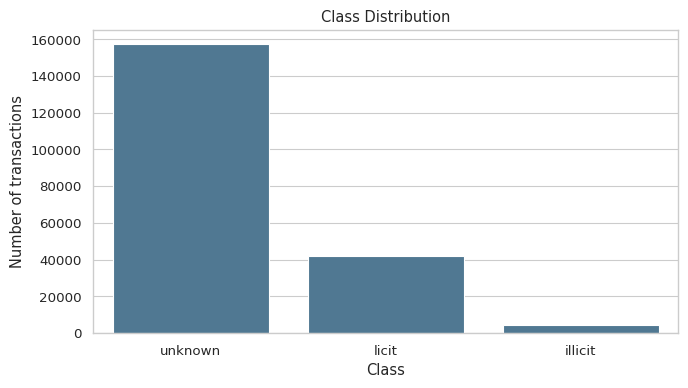

Saved table: /kaggle/working/tables/table_3_time_step_label_distribution.csv
Saved figure: /kaggle/working/figures/fig_2_time_step_distribution.png


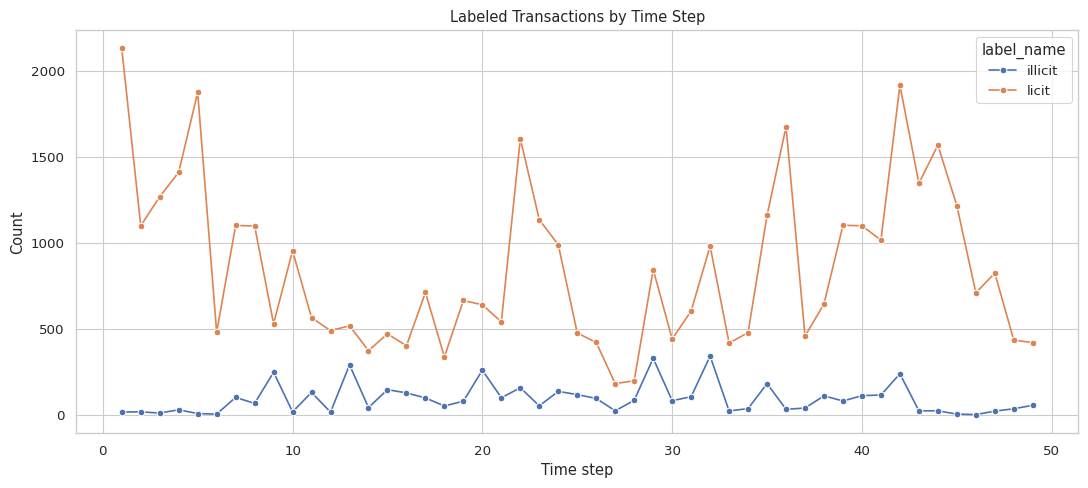

Saved table: /kaggle/working/tables/table_4_degree_summary.csv
Saved figure: /kaggle/working/figures/fig_3_degree_distribution.png


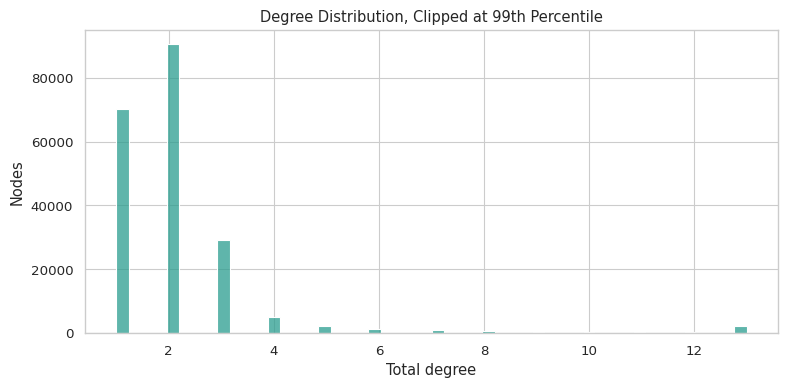

PosixPath('/kaggle/working/figures/fig_3_degree_distribution.png')

In [6]:
# ============================================================
# 4. Descriptive Statistics and Figures
# ============================================================

label_summary = (
    nodes.assign(label_name=nodes["label"].map({1: "illicit", 0: "licit", -1: "unknown"}))
    .groupby(["label", "label_name"], dropna=False)
    .size()
    .reset_index(name="count")
)
label_summary["share"] = label_summary["count"] / label_summary["count"].sum()
save_table(label_summary, "table_2_class_distribution.csv")

plt.figure(figsize=(7, 4))
sns.barplot(data=label_summary, x="label_name", y="count", color="#457B9D")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of transactions")
save_figure("fig_1_class_distribution.png")

time_label = (
    nodes[nodes["label"] >= 0]
    .assign(label_name=lambda d: d["label"].map({1: "illicit", 0: "licit"}))
    .groupby(["time_step", "label_name"])
    .size()
    .reset_index(name="count")
)
save_table(time_label, "table_3_time_step_label_distribution.csv")

plt.figure(figsize=(11, 5))
sns.lineplot(data=time_label, x="time_step", y="count", hue="label_name", marker="o")
plt.title("Labeled Transactions by Time Step")
plt.xlabel("Time step")
plt.ylabel("Count")
save_figure("fig_2_time_step_distribution.png")

deg_out = edges.groupby("src").size().rename("out_degree")
deg_in = edges.groupby("dst").size().rename("in_degree")
degree_df = nodes[["node_idx", "label", "time_step"]].merge(deg_in, left_on="node_idx", right_index=True, how="left")
degree_df = degree_df.merge(deg_out, left_on="node_idx", right_index=True, how="left")
degree_df[["in_degree", "out_degree"]] = degree_df[["in_degree", "out_degree"]].fillna(0).astype(int)
degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]
save_table(degree_df.describe().reset_index(), "table_4_degree_summary.csv")

plt.figure(figsize=(8, 4))
plot_deg = degree_df.loc[degree_df["total_degree"] > 0, "total_degree"]
plot_deg = plot_deg.clip(upper=plot_deg.quantile(0.99))
sns.histplot(plot_deg, bins=50, color="#2A9D8F")
plt.title("Degree Distribution, Clipped at 99th Percentile")
plt.xlabel("Total degree")
plt.ylabel("Nodes")
save_figure("fig_3_degree_distribution.png")

## Temporal Train/Validation/Test Split

The main split is temporal because AML models should generalize to future transactions. If the sample subset does not contain both classes in all splits, the notebook falls back to a stratified random split only to verify code execution. The full journal run should use the temporal split.

In [7]:
# ============================================================
# 5. Main Temporal Split
# ============================================================

def split_has_two_classes(df, mask):
    return df.loc[mask, "label"].nunique() == 2

def build_split(df):
    steps = sorted(df.loc[df["label"] >= 0, "time_step"].dropna().astype(int).unique())
    for train_frac, val_frac in [(0.70, 0.85), (0.65, 0.82), (0.60, 0.80), (0.55, 0.78)]:
        t = max(1, int(len(steps) * train_frac))
        v = max(t + 1, int(len(steps) * val_frac))
        train_steps, val_steps, test_steps = steps[:t], steps[t:v], steps[v:]
        train = (df["label"] >= 0) & df["time_step"].astype(int).isin(train_steps)
        val = (df["label"] >= 0) & df["time_step"].astype(int).isin(val_steps)
        test = (df["label"] >= 0) & df["time_step"].astype(int).isin(test_steps)
        if train.sum() and val.sum() and test.sum():
            if split_has_two_classes(df, train) and split_has_two_classes(df, val) and split_has_two_classes(df, test):
                return train.values, val.values, test.values, "temporal", train_steps, val_steps, test_steps

    print("WARNING: temporal sample split lacks both classes. Using stratified random fallback for pipeline testing.")
    idx = df.index[df["label"] >= 0].to_numpy()
    y = df.loc[idx, "label"].to_numpy()
    s1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
    tr_pos, temp_pos = next(s1.split(idx, y))
    tr_idx, temp_idx = idx[tr_pos], idx[temp_pos]
    s2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
    val_pos, te_pos = next(s2.split(temp_idx, df.loc[temp_idx, "label"]))
    val_idx, te_idx = temp_idx[val_pos], temp_idx[te_pos]
    train = np.zeros(len(df), dtype=bool); train[tr_idx] = True
    val = np.zeros(len(df), dtype=bool); val[val_idx] = True
    test = np.zeros(len(df), dtype=bool); test[te_idx] = True
    return train, val, test, "random_fallback", [], [], []

train_mask, val_mask, test_mask, split_type, train_steps, val_steps, test_steps = build_split(nodes)
split_summary = pd.DataFrame([
    summarize_target(nodes.loc[train_mask, "label"], "train"),
    summarize_target(nodes.loc[val_mask, "label"], "validation"),
    summarize_target(nodes.loc[test_mask, "label"], "test"),
])
split_summary["split_type"] = split_type
split_summary["train_steps"] = str(train_steps)
split_summary["validation_steps"] = str(val_steps)
split_summary["test_steps"] = str(test_steps)
save_table(split_summary, "table_5_split_summary.csv")
split_summary

Saved table: /kaggle/working/tables/table_5_split_summary.csv


,split,n,licit_count_label_0,illicit_count_label_1,illicit_rate,split_type,train_steps,validation_steps,test_steps
0,train,29894,26432,3462,0.115809,temporal,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(35), np.int64(36), np.int64(37), np....","[np.int64(42), np.int64(43), np.int64(44), np...."
1,validation,7829,7154,675,0.086218,temporal,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(35), np.int64(36), np.int64(37), np....","[np.int64(42), np.int64(43), np.int64(44), np...."
2,test,8841,8433,408,0.046149,temporal,"[np.int64(1), np.int64(2), np.int64(3), np.int...","[np.int64(35), np.int64(36), np.int64(37), np....","[np.int64(42), np.int64(43), np.int64(44), np...."


## Advanced Graph Feature Engineering

This section adds leakage-safe graph-derived features: in/out degree, temporal edge direction counts, PageRank/k-core when enabled, and training-label-only neighborhood risk features. Validation and test labels are never used as neighbor labels.

In [8]:
# ============================================================
# 5B. Leakage-Safe Graph Feature Engineering
# ============================================================

num_nodes = len(nodes)
src = edges["src"].to_numpy(dtype=np.int64)
dst = edges["dst"].to_numpy(dtype=np.int64)
time_values = nodes["time_step"].fillna(-1).astype(int).to_numpy()
node_labels = nodes["label"].to_numpy(dtype=np.int64)


def bc(index, weights=None):
    return np.bincount(index, weights=weights, minlength=num_nodes).astype(np.float32)


nodes["in_degree"] = bc(dst)
nodes["out_degree"] = bc(src)
nodes["total_degree"] = nodes["in_degree"] + nodes["out_degree"]
nodes["log_in_degree"] = np.log1p(nodes["in_degree"])
nodes["log_out_degree"] = np.log1p(nodes["out_degree"])
nodes["log_total_degree"] = np.log1p(nodes["total_degree"])
nodes["net_out_degree"] = nodes["out_degree"] - nodes["in_degree"]
nodes["degree_balance"] = nodes["net_out_degree"] / (nodes["total_degree"] + 1.0)
nodes["is_source_like"] = ((nodes["out_degree"] > 0) & (nodes["in_degree"] == 0)).astype("float32")
nodes["is_sink_like"] = ((nodes["in_degree"] > 0) & (nodes["out_degree"] == 0)).astype("float32")

src_time = time_values[src]
dst_time = time_values[dst]
nodes["in_from_past_count"] = bc(dst[dst_time > src_time])
nodes["in_from_future_count"] = bc(dst[dst_time < src_time])
nodes["in_same_time_count"] = bc(dst[dst_time == src_time])
nodes["out_to_future_count"] = bc(src[dst_time > src_time])
nodes["out_to_past_count"] = bc(src[dst_time < src_time])
nodes["out_same_time_count"] = bc(src[dst_time == src_time])

train_label_only = np.full(num_nodes, -1, dtype=np.int64)
train_label_only[train_mask] = node_labels[train_mask]
src_train_label = train_label_only[src]
dst_train_label = train_label_only[dst]

nodes["out_to_train_illicit"] = bc(src[dst_train_label == 1])
nodes["out_to_train_licit"] = bc(src[dst_train_label == 0])
nodes["in_from_train_illicit"] = bc(dst[src_train_label == 1])
nodes["in_from_train_licit"] = bc(dst[src_train_label == 0])
nodes["train_labeled_neighbor_count"] = (
    nodes["out_to_train_illicit"] + nodes["out_to_train_licit"] +
    nodes["in_from_train_illicit"] + nodes["in_from_train_licit"]
)
nodes["train_illicit_neighbor_share"] = (
    nodes["out_to_train_illicit"] + nodes["in_from_train_illicit"]
) / (nodes["train_labeled_neighbor_count"] + 1.0)

base_graph_feature_cols = [
    "in_degree", "out_degree", "total_degree", "log_in_degree", "log_out_degree", "log_total_degree",
    "net_out_degree", "degree_balance", "is_source_like", "is_sink_like",
    "in_from_past_count", "in_from_future_count", "in_same_time_count",
    "out_to_future_count", "out_to_past_count", "out_same_time_count",
    "out_to_train_illicit", "out_to_train_licit", "in_from_train_illicit", "in_from_train_licit",
    "train_labeled_neighbor_count", "train_illicit_neighbor_share",
]

networkx_feature_cols = []
if HAS_NETWORKX and RUN_EXPENSIVE_GRAPH_FEATURES:
    print("Computing NetworkX graph features: PageRank and k-core...")
    try:
        G_dir = nx.DiGraph()
        G_dir.add_nodes_from(range(num_nodes))
        G_dir.add_edges_from(zip(src.tolist(), dst.tolist()))
        pr = nx.pagerank(G_dir, alpha=0.85, max_iter=50, tol=1e-4)
        nodes["pagerank"] = pd.Series(pr).reindex(range(num_nodes)).fillna(0).astype("float32").to_numpy()
        networkx_feature_cols.append("pagerank")
    except Exception as e:
        print("PageRank failed; filling zeros:", repr(e))
        nodes["pagerank"] = 0.0
        networkx_feature_cols.append("pagerank")
    try:
        G_undir = nx.Graph()
        G_undir.add_nodes_from(range(num_nodes))
        G_undir.add_edges_from(zip(src.tolist(), dst.tolist()))
        core = nx.core_number(G_undir)
        nodes["k_core"] = pd.Series(core).reindex(range(num_nodes)).fillna(0).astype("float32").to_numpy()
        networkx_feature_cols.append("k_core")
        if RUN_LOCAL_CLUSTERING:
            clustering = nx.clustering(G_undir)
            nodes["local_clustering"] = pd.Series(clustering).reindex(range(num_nodes)).fillna(0).astype("float32").to_numpy()
            networkx_feature_cols.append("local_clustering")
    except Exception as e:
        print("k-core/clustering failed; filling conservative zeros:", repr(e))
        nodes["k_core"] = 0.0
        networkx_feature_cols.append("k_core")
else:
    print("NetworkX graph features skipped. Set RUN_EXPENSIVE_GRAPH_FEATURES=True to enable.")

graph_feature_cols = base_graph_feature_cols + networkx_feature_cols
save_table(pd.DataFrame({"graph_feature": graph_feature_cols}), "table_5b_graph_feature_dictionary.csv")
summary = nodes.loc[nodes["label"] >= 0, graph_feature_cols].describe().T.reset_index().rename(columns={"index": "feature"})
save_table(summary, "table_5c_graph_feature_summary.csv")
print("Graph feature columns:", len(graph_feature_cols))
summary.head()

Computing NetworkX graph features: PageRank and k-core...
Saved table: /kaggle/working/tables/table_5b_graph_feature_dictionary.csv
Saved table: /kaggle/working/tables/table_5c_graph_feature_summary.csv
Graph feature columns: 24


,feature,count,mean,std,min,25%,50%,75%,max
0,in_degree,46564.0,1.846985,7.134175,0.0,0.0,1.000000,1.000000,284.000000
1,out_degree,46564.0,1.142471,3.093221,0.0,0.0,1.000000,1.000000,472.000000
2,total_degree,46564.0,2.989455,7.733443,1.0,1.0,2.000000,3.000000,473.000000
3,log_in_degree,46564.0,0.641105,0.655418,0.0,0.0,0.693147,0.693147,5.652489
4,log_out_degree,46564.0,0.634221,0.454449,0.0,0.0,0.693147,0.693147,6.159095


## Graph Embedding Baselines

This section adds graph-structure embeddings: robust spectral/SVD embeddings and optional bounded DeepWalk/Node2Vec-style embeddings using `gensim` if available.

In [9]:
# ============================================================
# 5C. Spectral and Node2Vec-Style Graph Embeddings
# ============================================================

spectral_cols = []
node2vec_cols = []

if RUN_SPECTRAL_GRAPH_EMBEDDING and HAS_SCIPY:
    print("Computing spectral graph embeddings with TruncatedSVD...")
    row = np.concatenate([src, dst])
    col = np.concatenate([dst, src])
    data = np.ones(len(row), dtype=np.float32)
    A = sp.csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))
    deg = np.asarray(A.sum(axis=1)).ravel().astype(np.float32)
    inv_deg = np.divide(1.0, deg, out=np.zeros_like(deg), where=deg > 0)
    A_norm = sp.diags(inv_deg).dot(A)
    svd = TruncatedSVD(n_components=SPECTRAL_DIM, n_iter=7, random_state=RANDOM_SEED)
    spectral_emb = svd.fit_transform(A_norm).astype(np.float32)
    spectral_cols = [f"spectral_g_{i:02d}" for i in range(spectral_emb.shape[1])]
    for j, col_name in enumerate(spectral_cols):
        nodes[col_name] = spectral_emb[:, j]
    save_table(pd.DataFrame({
        "component": spectral_cols,
        "explained_variance_ratio": svd.explained_variance_ratio_,
    }), "table_5d_spectral_embedding_variance.csv")
    print("Spectral embedding columns:", len(spectral_cols))
else:
    print("Spectral embeddings skipped. HAS_SCIPY=", HAS_SCIPY)

if RUN_NODE2VEC_EMBEDDING:
    try:
        from gensim.models import Word2Vec
        print("Computing bounded DeepWalk/Node2Vec-style embeddings with gensim Word2Vec...")
        rng = np.random.default_rng(RANDOM_SEED)
        adj_lists = [[] for _ in range(num_nodes)]
        for a, b in zip(src, dst):
            adj_lists[int(a)].append(int(b))
            adj_lists[int(b)].append(int(a))
        all_starts = np.arange(num_nodes)
        if NODE2VEC_MAX_START_NODES is not None and NODE2VEC_MAX_START_NODES < num_nodes:
            labeled = np.where(nodes["label"].to_numpy() >= 0)[0]
            extra_needed = max(0, NODE2VEC_MAX_START_NODES - len(labeled))
            remaining = np.setdiff1d(all_starts, labeled, assume_unique=False)
            extra = rng.choice(remaining, size=min(extra_needed, len(remaining)), replace=False)
            start_nodes = np.unique(np.concatenate([labeled, extra]))
        else:
            start_nodes = all_starts

        walks = []
        for start in start_nodes:
            for _ in range(NODE2VEC_WALKS_PER_NODE):
                walk = [int(start)]
                cur = int(start)
                for _step in range(NODE2VEC_WALK_LENGTH - 1):
                    neigh = adj_lists[cur]
                    if not neigh:
                        break
                    cur = int(rng.choice(neigh))
                    walk.append(cur)
                walks.append([str(x) for x in walk])
        print("Random walks:", len(walks))
        w2v = Word2Vec(
            sentences=walks,
            vector_size=NODE2VEC_DIM,
            window=5,
            min_count=1,
            sg=1,
            workers=2,
            epochs=3 if SAMPLE_MODE else 5,
            seed=RANDOM_SEED,
        )
        emb = np.zeros((num_nodes, NODE2VEC_DIM), dtype=np.float32)
        for i in range(num_nodes):
            key = str(i)
            if key in w2v.wv:
                emb[i] = w2v.wv[key]
        node2vec_cols = [f"node2vec_g_{i:02d}" for i in range(NODE2VEC_DIM)]
        for j, col_name in enumerate(node2vec_cols):
            nodes[col_name] = emb[:, j]
        save_table(pd.DataFrame({"node2vec_feature": node2vec_cols}), "table_5e_node2vec_feature_dictionary.csv")
        print("Node2Vec-style embedding columns:", len(node2vec_cols))
    except Exception as e:
        print("Node2Vec-style embeddings skipped because gensim/random-walk training failed:", repr(e))
        node2vec_cols = []
else:
    print("Node2Vec-style embeddings disabled by RUN_NODE2VEC_EMBEDDING=False")

Computing spectral graph embeddings with TruncatedSVD...
Saved table: /kaggle/working/tables/table_5d_spectral_embedding_variance.csv
Spectral embedding columns: 32
Computing bounded DeepWalk/Node2Vec-style embeddings with gensim Word2Vec...
Random walks: 60000
Saved table: /kaggle/working/tables/table_5e_node2vec_feature_dictionary.csv
Node2Vec-style embedding columns: 32


In [10]:
# ============================================================
# 6. Feature Matrices and Feature-Set Registry
# ============================================================

X_all = nodes[feature_cols].to_numpy(dtype=np.float32)
y_all = nodes["label"].to_numpy(dtype=np.int64)

scaler = StandardScaler()
scaler.fit(X_all[train_mask])
X_all_scaled = scaler.transform(X_all).astype(np.float32)

X_train, y_train = X_all_scaled[train_mask], y_all[train_mask]
X_val, y_val = X_all_scaled[val_mask], y_all[val_mask]
X_test, y_test = X_all_scaled[test_mask], y_all[test_mask]

feature_sets = {
    "tabular_original": list(feature_cols),
    "graph_handcrafted": list(graph_feature_cols),
    "tabular_plus_graph": list(feature_cols) + list(graph_feature_cols),
}
if len(spectral_cols) > 0:
    feature_sets["spectral_graph_embedding"] = list(spectral_cols)
    feature_sets["tabular_plus_graph_plus_spectral"] = list(feature_cols) + list(graph_feature_cols) + list(spectral_cols)
if len(node2vec_cols) > 0:
    feature_sets["node2vec_embedding"] = list(node2vec_cols)
    feature_sets["tabular_plus_graph_plus_node2vec"] = list(feature_cols) + list(graph_feature_cols) + list(node2vec_cols)
    if len(spectral_cols) > 0:
        feature_sets["all_features"] = list(feature_cols) + list(graph_feature_cols) + list(spectral_cols) + list(node2vec_cols)

feature_set_matrices = {}
feature_set_scalers = {}
for set_name, cols in feature_sets.items():
    X_scaled, sc = scale_columns_for_split(nodes, cols, train_mask)
    feature_set_matrices[set_name] = {
        "X_all": X_scaled,
        "X_train": X_scaled[train_mask],
        "X_val": X_scaled[val_mask],
        "X_test": X_scaled[test_mask],
        "n_features": len(cols),
        "columns": cols,
    }
    feature_set_scalers[set_name] = sc

feature_set_summary = pd.DataFrame([
    {"feature_set": k, "n_features": v["n_features"]}
    for k, v in feature_set_matrices.items()
])
save_table(feature_set_summary, "table_5f_feature_set_registry.csv")

print("Train:", X_train.shape, "positive rate:", y_train.mean())
print("Validation:", X_val.shape, "positive rate:", y_val.mean())
print("Test:", X_test.shape, "positive rate:", y_test.mean())
feature_set_summary

Saved table: /kaggle/working/tables/table_5f_feature_set_registry.csv
Train: (29894, 165) positive rate: 0.11580919248009634
Validation: (7829, 165) positive rate: 0.08621790777877124
Test: (8841, 165) positive rate: 0.04614862572107228


,feature_set,n_features
0,tabular_original,165
1,graph_handcrafted,24
2,tabular_plus_graph,189
3,spectral_graph_embedding,32
4,tabular_plus_graph_plus_spectral,221
5,node2vec_embedding,32
6,tabular_plus_graph_plus_node2vec,221
7,all_features,253


## Model Family 1: Transaction-Feature-Only Machine Learning

These baselines ignore graph edges. They are necessary because the Elliptic dataset includes strong engineered transaction features. A graph model must beat strong tabular models to claim practical AML value.

In [11]:
# ============================================================
# 7. Classical ML Models
# ============================================================

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
pos = max(1, int((y_train == 1).sum()))
neg = max(1, int((y_train == 0).sum()))
scale_pos_weight = neg / pos

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=TREE_ESTIMATORS, max_depth=18 if SAMPLE_MODE else None, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_SEED),
    "Extra Trees": ExtraTreesClassifier(n_estimators=TREE_ESTIMATORS, max_depth=20 if SAMPLE_MODE else None, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=120 if SAMPLE_MODE else 250, learning_rate=0.06, max_leaf_nodes=31, l2_regularization=0.05, random_state=RANDOM_SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), alpha=1e-4, learning_rate_init=1e-3, max_iter=80 if SAMPLE_MODE else 160, early_stopping=True, validation_fraction=0.15, random_state=RANDOM_SEED),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=160 if SAMPLE_MODE else 450,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

trained_models = {}
model_predictions = {}

for name, model in models.items():
    print("\\nTraining", name)
    start = time.time()
    if name == "HistGradientBoosting":
        model.fit(X_train, y_train, sample_weight=sample_weights)
    elif name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    else:
        model.fit(X_train, y_train)
    seconds = time.time() - start
    prob = model.predict_proba(X_test)[:, 1]
    trained_models[name] = model
    model_predictions[name] = {
        "test_prob": prob,
        "val_prob": model.predict_proba(X_val)[:, 1],
        "family": "tabular_ml",
        "train_seconds": seconds,
    }
    print(f"{name}: seconds={seconds:.1f}, test AUPRC={safe_average_precision(y_test, prob):.4f}, test AUROC={safe_roc_auc(y_test, prob):.4f}")

\nTraining Logistic Regression
Logistic Regression: seconds=3.1, test AUPRC=0.1987, test AUROC=0.8554
\nTraining Random Forest
Random Forest: seconds=16.6, test AUPRC=0.5434, test AUROC=0.8504
\nTraining Extra Trees
Extra Trees: seconds=4.9, test AUPRC=0.5699, test AUROC=0.8695
\nTraining HistGradientBoosting
HistGradientBoosting: seconds=4.7, test AUPRC=0.5597, test AUROC=0.8716
\nTraining MLP
MLP: seconds=3.2, test AUPRC=0.4459, test AUROC=0.8446
\nTraining XGBoost
XGBoost: seconds=5.0, test AUPRC=0.5533, test AUROC=0.8628


## Advanced Ablation Models: Tabular, Graph Features, and Graph Embeddings

A top-tier version needs to separate the value of transaction features, handcrafted graph structure, and learned graph embeddings. This section trains strong tabular classifiers on multiple feature sets.

In [12]:
# ============================================================
# 7B. Feature-Set Ablation Models
# ============================================================

advanced_model_predictions = {}
advanced_trained_models = {}
ablation_feature_sets = [fs for fs in feature_set_matrices.keys() if fs != "tabular_original"]
print("Ablation feature sets:", ablation_feature_sets)


def make_ablation_models(y_train_local):
    pos_local = max(1, int((y_train_local == 1).sum()))
    neg_local = max(1, int((y_train_local == 0).sum()))
    model_dict = {
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=max(120, TREE_ESTIMATORS // 2),
            max_depth=24 if SAMPLE_MODE else None,
            min_samples_leaf=2,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_SEED,
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            max_iter=100 if SAMPLE_MODE else 220,
            learning_rate=0.06,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=RANDOM_SEED,
        ),
    }
    if HAS_XGBOOST:
        model_dict["XGBoost"] = XGBClassifier(
            n_estimators=120 if SAMPLE_MODE else 300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=neg_local / pos_local,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
    return model_dict


for fs_name in ablation_feature_sets:
    mats = feature_set_matrices[fs_name]
    Xtr, Xva, Xte = mats["X_train"], mats["X_val"], mats["X_test"]
    sw = compute_sample_weight(class_weight="balanced", y=y_train)
    for model_short, model in make_ablation_models(y_train).items():
        model_name = f"{model_short}__{fs_name}"
        print("\nTraining ablation model:", model_name, "features=", mats["n_features"])
        start = time.time()
        if model_short == "HistGradientBoosting":
            model.fit(Xtr, y_train, sample_weight=sw)
        elif model_short == "XGBoost":
            model.fit(Xtr, y_train, eval_set=[(Xva, y_val)], verbose=False)
        else:
            model.fit(Xtr, y_train)
        seconds = time.time() - start
        prob_test = model.predict_proba(Xte)[:, 1]
        prob_val = model.predict_proba(Xva)[:, 1]
        advanced_trained_models[model_name] = model
        advanced_model_predictions[model_name] = {
            "test_prob": prob_test,
            "val_prob": prob_val,
            "family": "feature_ablation",
            "feature_set": fs_name,
            "train_seconds": seconds,
        }
        model_predictions[model_name] = advanced_model_predictions[model_name]
        print(f"{model_name}: test AUPRC={safe_average_precision(y_test, prob_test):.4f}, AUROC={safe_roc_auc(y_test, prob_test):.4f}, seconds={seconds:.1f}")

ablation_quick = pd.DataFrame([
    {"model": name, "feature_set": pred.get("feature_set"), **compute_metrics(y_test, pred["test_prob"], k_frac=PRECISION_RECALL_AT_K_FRAC)}
    for name, pred in advanced_model_predictions.items()
]).sort_values("auprc", ascending=False)
save_table(ablation_quick, "table_7b_feature_set_ablation_quick_results.csv")
ablation_quick.head(20)

Ablation feature sets: ['graph_handcrafted', 'tabular_plus_graph', 'spectral_graph_embedding', 'tabular_plus_graph_plus_spectral', 'node2vec_embedding', 'tabular_plus_graph_plus_node2vec', 'all_features']

Training ablation model: ExtraTrees__graph_handcrafted features= 24
ExtraTrees__graph_handcrafted: test AUPRC=0.0673, AUROC=0.6651, seconds=0.9

Training ablation model: HistGradientBoosting__graph_handcrafted features= 24
HistGradientBoosting__graph_handcrafted: test AUPRC=0.0665, AUROC=0.6567, seconds=0.7

Training ablation model: XGBoost__graph_handcrafted features= 24
XGBoost__graph_handcrafted: test AUPRC=0.0681, AUROC=0.6632, seconds=0.6

Training ablation model: ExtraTrees__tabular_plus_graph features= 189
ExtraTrees__tabular_plus_graph: test AUPRC=0.5496, AUROC=0.8468, seconds=3.3

Training ablation model: HistGradientBoosting__tabular_plus_graph features= 189
HistGradientBoosting__tabular_plus_graph: test AUPRC=0.5307, AUROC=0.8403, seconds=4.3

Training ablation model: XGBo

,model,feature_set,accuracy,precision,recall,f1,auroc,auprc,brier,precision_at_k,recall_at_k,k
15,ExtraTrees__tabular_plus_graph_plus_node2vec,tabular_plus_graph_plus_node2vec,0.973872,0.958549,0.453431,0.615641,0.851793,0.553424,0.027905,0.446953,0.485294,443
9,ExtraTrees__tabular_plus_graph_plus_spectral,tabular_plus_graph_plus_spectral,0.974098,0.954315,0.460784,0.621488,0.846312,0.550055,0.028396,0.446953,0.485294,443
3,ExtraTrees__tabular_plus_graph,tabular_plus_graph,0.973872,0.949239,0.458333,0.618182,0.846833,0.549593,0.028476,0.444695,0.482843,443
18,ExtraTrees__all_features,all_features,0.973646,0.953368,0.450980,0.612313,0.844329,0.547274,0.028375,0.444695,0.482843,443
5,XGBoost__tabular_plus_graph,tabular_plus_graph,0.946952,0.433260,0.485294,0.457803,0.841570,0.538102,0.044959,0.446953,0.485294,443
10,HistGradientBoosting__tabular_plus_graph_plus_...,tabular_plus_graph_plus_spectral,0.957358,0.542466,0.485294,0.512290,0.843043,0.533736,0.036908,0.446953,0.485294,443
11,XGBoost__tabular_plus_graph_plus_spectral,tabular_plus_graph_plus_spectral,0.939600,0.379310,0.485294,0.425806,0.838727,0.533612,0.049873,0.444695,0.482843,443
19,HistGradientBoosting__all_features,all_features,0.956340,0.529891,0.477941,0.502577,0.847182,0.533368,0.037967,0.446953,0.485294,443
17,XGBoost__tabular_plus_graph_plus_node2vec,tabular_plus_graph_plus_node2vec,0.946160,0.426407,0.482843,0.452874,0.836152,0.533339,0.045542,0.444695,0.482843,443
20,XGBoost__all_features,all_features,0.935188,0.352415,0.482843,0.407446,0.830881,0.531741,0.052290,0.444695,0.482843,443


## Model Family 2: Pure-PyTorch Graph Neural Networks

The notebook implements GCN and GraphSAGE directly with sparse PyTorch operations. This avoids the installation risk of PyTorch Geometric on Kaggle Free Tier. Unknown-label nodes remain in the graph structure, but loss and metrics use labeled masks only.

In [13]:
# ============================================================
# 8. Sparse Graph and GNN Models
# ============================================================

def build_sparse_adj(edge_df, num_nodes, norm, device):
    src = edge_df["src"].to_numpy(dtype=np.int64)
    dst = edge_df["dst"].to_numpy(dtype=np.int64)
    row = np.concatenate([src, dst, np.arange(num_nodes)])
    col = np.concatenate([dst, src, np.arange(num_nodes)])
    row_t = torch.tensor(row, dtype=torch.long)
    col_t = torch.tensor(col, dtype=torch.long)
    deg = torch.bincount(row_t, minlength=num_nodes).float().clamp(min=1.0)
    if norm == "gcn":
        val = deg[row_t].pow(-0.5) * deg[col_t].pow(-0.5)
    else:
        val = 1.0 / deg[row_t]
    idx = torch.stack([row_t, col_t], dim=0)
    return torch.sparse_coo_tensor(idx, val.float(), (num_nodes, num_nodes)).coalesce().to(device)

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.35):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)
        self.dropout = dropout
    def forward(self, x, adj):
        h = torch.sparse.mm(adj, x)
        h = F.relu(self.lin1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = torch.sparse.mm(adj, h)
        return self.lin2(h).squeeze(-1)

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, dropout=0.35):
        super().__init__()
        self.lin1 = nn.Linear(in_dim * 2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim * 2, 1)
        self.dropout = dropout
    def forward(self, x, adj):
        n1 = torch.sparse.mm(adj, x)
        h = F.relu(self.lin1(torch.cat([x, n1], dim=1)))
        h = F.dropout(h, p=self.dropout, training=self.training)
        n2 = torch.sparse.mm(adj, h)
        return self.lin2(torch.cat([h, n2], dim=1)).squeeze(-1)

device = TORCH_DEVICE
X_torch = torch.tensor(X_all_scaled, dtype=torch.float32, device=device)
y_torch = torch.tensor(y_all, dtype=torch.float32, device=device)
train_t = torch.tensor(train_mask, dtype=torch.bool, device=device)
val_t = torch.tensor(val_mask, dtype=torch.bool, device=device)
test_t = torch.tensor(test_mask, dtype=torch.bool, device=device)

adj_gcn = build_sparse_adj(edges, len(nodes), "gcn", device)
adj_mean = build_sparse_adj(edges, len(nodes), "mean", device)
print("Device:", device, "GCN adjacency nnz:", adj_gcn._nnz())

Device: cpu GCN adjacency nnz: 672479


In [14]:
# ============================================================
# 9. Train GNN Models
# ============================================================

def train_gnn(model_name, model, adj):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = torch.sum(y_torch[train_t] == 1).item()
    neg = torch.sum(y_torch[train_t] == 0).item()
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([max(1.0, neg / max(1.0, pos))], device=device))
    best_state, best_val, best_epoch = None, -np.inf, 0
    history = []
    for epoch in range(1, GNN_EPOCHS + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        logits = model(X_torch, adj)
        loss = criterion(logits[train_t], y_torch[train_t])
        loss.backward()
        opt.step()
        if epoch == 1 or epoch % 5 == 0 or epoch == GNN_EPOCHS:
            model.eval()
            with torch.no_grad():
                p_val = torch.sigmoid(model(X_torch, adj)[val_t]).detach().cpu().numpy()
            val_ap = safe_average_precision(y_val, p_val)
            val_auc = safe_roc_auc(y_val, p_val)
            history.append({"epoch": epoch, "loss": float(loss.item()), "val_auprc": val_ap, "val_auroc": val_auc})
            print(f"{model_name} epoch {epoch:03d}: loss={loss.item():.4f}, val_AUPRC={val_ap:.4f}, val_AUROC={val_auc:.4f}")
            monitor = val_ap if not np.isnan(val_ap) else -float(loss.item())
            if monitor > best_val:
                best_val, best_epoch = monitor, epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            elif epoch - best_epoch >= GNN_PATIENCE:
                print("Early stopping at epoch", epoch)
                break
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    hist = pd.DataFrame(history)
    save_table(hist, f"training_history_{model_name.lower()}.csv")
    torch.save(model.state_dict(), MODEL_DIR / f"{model_name.lower()}.pt")
    return model

def gnn_probs(model, adj):
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_torch, adj)).detach().cpu().numpy()

for name, model, adj in [
    ("GCN", GCN(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_gcn),
    ("GraphSAGE", GraphSAGE(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_mean),
]:
    print("\\nTraining", name)
    start = time.time()
    model = train_gnn(name, model, adj)
    seconds = time.time() - start
    p_all = gnn_probs(model, adj)
    model_predictions[name] = {
        "test_prob": p_all[test_mask],
        "val_prob": p_all[val_mask],
        "all_prob": p_all,
        "family": "graph_ai",
        "train_seconds": seconds,
    }
    print(f"{name}: seconds={seconds:.1f}, test AUPRC={safe_average_precision(y_test, p_all[test_mask]):.4f}, test AUROC={safe_roc_auc(y_test, p_all[test_mask]):.4f}")

if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

\nTraining GCN
GCN epoch 001: loss=1.2579, val_AUPRC=0.0660, val_AUROC=0.4056
GCN epoch 005: loss=1.1348, val_AUPRC=0.1612, val_AUROC=0.7351
GCN epoch 010: loss=1.0345, val_AUPRC=0.1759, val_AUROC=0.7629
GCN epoch 015: loss=0.9654, val_AUPRC=0.1828, val_AUROC=0.7711
GCN epoch 020: loss=0.9071, val_AUPRC=0.1881, val_AUROC=0.7753
GCN epoch 025: loss=0.8555, val_AUPRC=0.1941, val_AUROC=0.7774
GCN epoch 030: loss=0.8061, val_AUPRC=0.1993, val_AUROC=0.7788
GCN epoch 035: loss=0.7697, val_AUPRC=0.2064, val_AUROC=0.7817
GCN epoch 040: loss=0.7267, val_AUPRC=0.2180, val_AUROC=0.7873
GCN epoch 045: loss=0.6926, val_AUPRC=0.2355, val_AUROC=0.7951
GCN epoch 050: loss=0.6572, val_AUPRC=0.2543, val_AUROC=0.8036
GCN epoch 055: loss=0.6278, val_AUPRC=0.2713, val_AUROC=0.8113
GCN epoch 060: loss=0.6071, val_AUPRC=0.2859, val_AUROC=0.8188
GCN epoch 065: loss=0.5806, val_AUPRC=0.3005, val_AUROC=0.8260
GCN epoch 070: loss=0.5588, val_AUPRC=0.3139, val_AUROC=0.8322
GCN epoch 075: loss=0.5430, val_AUPRC=0.

41

## Stronger Graph Neural Baselines

This section adds stronger graph baselines: Residual GCN and a lightweight attention model (`GATLite`) implemented with PyTorch scatter operations when supported.

In [15]:
# ============================================================
# 9B. Residual GCN and Lightweight GAT
# ============================================================

class ResidualGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, layers=3, dropout=0.35, alpha=0.25):
        super().__init__()
        self.input = nn.Linear(in_dim, hidden_dim)
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(layers)])
        self.output = nn.Linear(hidden_dim, 1)
        self.dropout = dropout
        self.alpha = alpha

    def forward(self, x, adj):
        h0 = F.relu(self.input(torch.sparse.mm(adj, x)))
        h = h0
        for layer in self.layers:
            z = F.relu(layer(torch.sparse.mm(adj, h)))
            h = self.alpha * h0 + (1.0 - self.alpha) * z
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.output(h).squeeze(-1)


print("\nTraining graph model: ResidualGCN")
start = time.time()
res_gcn = train_gnn("ResidualGCN", ResidualGCN(len(feature_cols), hidden_dim=64 if SAMPLE_MODE else 96), adj_gcn)
seconds = time.time() - start
p_all = gnn_probs(res_gcn, adj_gcn)
model_predictions["ResidualGCN"] = {
    "test_prob": p_all[test_mask],
    "val_prob": p_all[val_mask],
    "all_prob": p_all,
    "family": "graph_ai",
    "train_seconds": seconds,
}
print(f"ResidualGCN: seconds={seconds:.1f}, test AUPRC={safe_average_precision(y_test, p_all[test_mask]):.4f}, test AUROC={safe_roc_auc(y_test, p_all[test_mask]):.4f}")


class GATLite(nn.Module):
    def __init__(self, in_dim, hidden_dim=48, dropout=0.35, negative_slope=0.2):
        super().__init__()
        self.lin = nn.Linear(in_dim, hidden_dim, bias=False)
        self.att_row = nn.Parameter(torch.empty(hidden_dim))
        self.att_col = nn.Parameter(torch.empty(hidden_dim))
        self.out = nn.Linear(hidden_dim, 1)
        self.dropout = dropout
        self.negative_slope = negative_slope
        nn.init.xavier_uniform_(self.lin.weight)
        nn.init.normal_(self.att_row, std=0.1)
        nn.init.normal_(self.att_col, std=0.1)

    def forward(self, x, edge_index):
        h = self.lin(x)
        row, col = edge_index[0], edge_index[1]
        e = F.leaky_relu((h[row] * self.att_row).sum(dim=1) + (h[col] * self.att_col).sum(dim=1), negative_slope=self.negative_slope)
        max_per_row = torch.full((h.shape[0],), -1e9, dtype=e.dtype, device=e.device)
        max_per_row.scatter_reduce_(0, row, e, reduce="amax", include_self=True)
        exp_e = torch.exp(e - max_per_row[row])
        denom = torch.zeros(h.shape[0], dtype=e.dtype, device=e.device)
        denom.scatter_add_(0, row, exp_e)
        alpha = exp_e / (denom[row] + 1e-12)
        msg = h[col] * alpha.unsqueeze(1)
        out = torch.zeros_like(h)
        out.index_add_(0, row, msg)
        out = F.elu(out)
        out = F.dropout(out, p=self.dropout, training=self.training)
        return self.out(out).squeeze(-1)


def train_gat_lite(model, edge_index, epochs):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = torch.sum(y_torch[train_t] == 1).item()
    neg = torch.sum(y_torch[train_t] == 0).item()
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([max(1.0, neg / max(1.0, pos))], device=device))
    best_state, best_val, best_epoch = None, -np.inf, 0
    hist = []
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        logits = model(X_torch, edge_index)
        loss = criterion(logits[train_t], y_torch[train_t])
        loss.backward()
        opt.step()
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                p_val = torch.sigmoid(model(X_torch, edge_index)[val_t]).detach().cpu().numpy()
            val_ap = safe_average_precision(y_val, p_val)
            val_auc = safe_roc_auc(y_val, p_val)
            hist.append({"epoch": epoch, "loss": float(loss.item()), "val_auprc": val_ap, "val_auroc": val_auc})
            print(f"GATLite epoch {epoch:03d}: loss={loss.item():.4f}, val_AUPRC={val_ap:.4f}, val_AUROC={val_auc:.4f}")
            monitor = val_ap if not np.isnan(val_ap) else -float(loss.item())
            if monitor > best_val:
                best_val, best_epoch = monitor, epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            elif epoch - best_epoch >= max(5, GNN_PATIENCE // 2):
                print("Early stopping GATLite at epoch", epoch)
                break
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    save_table(pd.DataFrame(hist), "training_history_gatlite.csv")
    torch.save(model.state_dict(), MODEL_DIR / "gatlite.pt")
    return model


if RUN_GAT_LITE:
    try:
        row = np.concatenate([src, dst, np.arange(num_nodes)])
        col = np.concatenate([dst, src, np.arange(num_nodes)])
        edge_index = torch.tensor(np.vstack([row, col]), dtype=torch.long, device=device)
        print("\nTraining graph model: GATLite")
        start = time.time()
        gat = train_gat_lite(GATLite(len(feature_cols), hidden_dim=32 if SAMPLE_MODE else 48), edge_index, GAT_EPOCHS)
        seconds = time.time() - start
        gat.eval()
        with torch.no_grad():
            p_all = torch.sigmoid(gat(X_torch, edge_index)).detach().cpu().numpy()
        model_predictions["GATLite"] = {
            "test_prob": p_all[test_mask],
            "val_prob": p_all[val_mask],
            "all_prob": p_all,
            "family": "graph_ai",
            "train_seconds": seconds,
        }
        print(f"GATLite: seconds={seconds:.1f}, test AUPRC={safe_average_precision(y_test, p_all[test_mask]):.4f}, test AUROC={safe_roc_auc(y_test, p_all[test_mask]):.4f}")
    except Exception as e:
        print("GATLite skipped because this PyTorch runtime does not support the required scatter operations or memory budget:", repr(e))
else:
    print("GATLite disabled by RUN_GAT_LITE=False")

if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()


Training graph model: ResidualGCN
ResidualGCN epoch 001: loss=1.2382, val_AUPRC=0.1621, val_AUROC=0.7531
ResidualGCN epoch 005: loss=1.1920, val_AUPRC=0.2597, val_AUROC=0.7962
ResidualGCN epoch 010: loss=1.1326, val_AUPRC=0.2635, val_AUROC=0.7907
ResidualGCN epoch 015: loss=1.0505, val_AUPRC=0.2298, val_AUROC=0.7852
ResidualGCN epoch 020: loss=0.9387, val_AUPRC=0.2093, val_AUROC=0.7795
ResidualGCN epoch 025: loss=0.8247, val_AUPRC=0.2008, val_AUROC=0.7731
Early stopping at epoch 25
Saved table: /kaggle/working/tables/training_history_residualgcn.csv
ResidualGCN: seconds=99.2, test AUPRC=0.1266, test AUROC=0.7725

Training graph model: GATLite
GATLite epoch 001: loss=1.3890, val_AUPRC=0.0952, val_AUROC=0.5914
GATLite epoch 005: loss=1.1666, val_AUPRC=0.1939, val_AUROC=0.7750
GATLite epoch 010: loss=1.0344, val_AUPRC=0.3279, val_AUROC=0.8181
GATLite epoch 015: loss=0.9467, val_AUPRC=0.3497, val_AUROC=0.8170
GATLite epoch 020: loss=0.8964, val_AUPRC=0.3490, val_AUROC=0.8084
GATLite epoch

18

## Leakage-Sensitivity Check: Strict Temporal GNN

The earlier GNN cells use the full graph for message passing, which is common in transductive graph benchmarks but can be questioned in temporal AML evaluation. This section trains GNN weights using only train-period edges, validates with edges available through the validation period, and tests with edges available through the test period.

This does not make the benchmark perfectly causal at transaction timestamp level, but it is a stricter temporal sensitivity check than a single full-graph transductive run.

In [16]:
# ============================================================
# 9C. Strict Temporal GNN Sensitivity Check
# ============================================================

def edge_subset_until_time(max_time_step):
    src_t = nodes.loc[edges["src"].to_numpy(), "time_step"].fillna(-1).astype(int).to_numpy()
    dst_t = nodes.loc[edges["dst"].to_numpy(), "time_step"].fillna(-1).astype(int).to_numpy()
    keep = (src_t <= max_time_step) & (dst_t <= max_time_step)
    return edges.loc[keep].copy()


def train_gnn_strict_temporal(model_name, model, adj_train, adj_val, adj_test, epochs):
    model = model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    pos = torch.sum(y_torch[train_t] == 1).item()
    neg = torch.sum(y_torch[train_t] == 0).item()
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([max(1.0, neg / max(1.0, pos))], device=device))
    best_state, best_val, best_epoch = None, -np.inf, 0
    hist = []
    for epoch in range(1, epochs + 1):
        model.train()
        opt.zero_grad(set_to_none=True)
        logits = model(X_torch, adj_train)
        loss = criterion(logits[train_t], y_torch[train_t])
        loss.backward()
        opt.step()
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                p_val = torch.sigmoid(model(X_torch, adj_val)[val_t]).detach().cpu().numpy()
            val_ap = safe_average_precision(y_val, p_val)
            val_auc = safe_roc_auc(y_val, p_val)
            hist.append({"epoch": epoch, "loss": float(loss.item()), "val_auprc": val_ap, "val_auroc": val_auc})
            print(f"{model_name} epoch {epoch:03d}: loss={loss.item():.4f}, val_AUPRC={val_ap:.4f}, val_AUROC={val_auc:.4f}")
            monitor = val_ap if not np.isnan(val_ap) else -float(loss.item())
            if monitor > best_val:
                best_val, best_epoch = monitor, epoch
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            elif epoch - best_epoch >= max(5, GNN_PATIENCE // 2):
                print("Early stopping strict temporal GNN at epoch", epoch)
                break
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    model.eval()
    with torch.no_grad():
        p_all_test = torch.sigmoid(model(X_torch, adj_test)).detach().cpu().numpy()
    save_table(pd.DataFrame(hist), f"training_history_{model_name.lower().replace(' ', '_')}.csv")
    return p_all_test


if RUN_STRICT_TEMPORAL_GNN and split_type == "temporal" and len(train_steps) and len(val_steps) and len(test_steps):
    train_max_step = int(max(train_steps))
    val_max_step = int(max(val_steps))
    test_max_step = int(max(test_steps))

    edges_train_temporal = edge_subset_until_time(train_max_step)
    edges_val_temporal = edge_subset_until_time(val_max_step)
    edges_test_temporal = edge_subset_until_time(test_max_step)
    print("Strict temporal edge counts:", len(edges_train_temporal), len(edges_val_temporal), len(edges_test_temporal))

    adj_train_gcn = build_sparse_adj(edges_train_temporal, num_nodes, "gcn", device)
    adj_val_gcn = build_sparse_adj(edges_val_temporal, num_nodes, "gcn", device)
    adj_test_gcn = build_sparse_adj(edges_test_temporal, num_nodes, "gcn", device)
    adj_train_mean = build_sparse_adj(edges_train_temporal, num_nodes, "mean", device)
    adj_val_mean = build_sparse_adj(edges_val_temporal, num_nodes, "mean", device)
    adj_test_mean = build_sparse_adj(edges_test_temporal, num_nodes, "mean", device)

    for strict_name, strict_model, a_tr, a_va, a_te in [
        ("StrictTemporalGCN", GCN(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_train_gcn, adj_val_gcn, adj_test_gcn),
        ("StrictTemporalGraphSAGE", GraphSAGE(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_train_mean, adj_val_mean, adj_test_mean),
    ]:
        print("\nTraining", strict_name)
        start = time.time()
        p_all = train_gnn_strict_temporal(strict_name, strict_model, a_tr, a_va, a_te, STRICT_TEMPORAL_GNN_EPOCHS)
        seconds = time.time() - start
        model_predictions[strict_name] = {
            "test_prob": p_all[test_mask],
            "val_prob": p_all[val_mask],
            "all_prob": p_all,
            "family": "strict_temporal_graph_ai",
            "train_seconds": seconds,
        }
        print(f"{strict_name}: seconds={seconds:.1f}, test AUPRC={safe_average_precision(y_test, p_all[test_mask]):.4f}, test AUROC={safe_roc_auc(y_test, p_all[test_mask]):.4f}")
else:
    print("Strict temporal GNN skipped. Requires RUN_STRICT_TEMPORAL_GNN=True and a temporal split.")

if device.type == "cuda":
    torch.cuda.empty_cache()
gc.collect()

Strict temporal edge counts: 156843 192203 234355

Training StrictTemporalGCN
StrictTemporalGCN epoch 001: loss=1.3200, val_AUPRC=0.0965, val_AUROC=0.5895
StrictTemporalGCN epoch 005: loss=1.1890, val_AUPRC=0.1378, val_AUROC=0.7198
StrictTemporalGCN epoch 010: loss=1.0663, val_AUPRC=0.2027, val_AUROC=0.7973
StrictTemporalGCN epoch 015: loss=0.9900, val_AUPRC=0.2000, val_AUROC=0.7927
StrictTemporalGCN epoch 020: loss=0.9330, val_AUPRC=0.2004, val_AUROC=0.7886
Early stopping strict temporal GNN at epoch 20
Saved table: /kaggle/working/tables/training_history_stricttemporalgcn.csv
StrictTemporalGCN: seconds=26.2, test AUPRC=0.0953, test AUROC=0.7422

Training StrictTemporalGraphSAGE
StrictTemporalGraphSAGE epoch 001: loss=1.2409, val_AUPRC=0.1334, val_AUROC=0.6942
StrictTemporalGraphSAGE epoch 005: loss=0.9832, val_AUPRC=0.3195, val_AUROC=0.8310
StrictTemporalGraphSAGE epoch 010: loss=0.8274, val_AUPRC=0.3298, val_AUROC=0.8279
StrictTemporalGraphSAGE epoch 015: loss=0.7249, val_AUPRC=0.33

0

## Main Evaluation With 95 Percent Confidence Intervals

Every model is evaluated on the main test split using accuracy, precision, recall, F1, AUROC, AUPRC, Brier score, Precision@K, and Recall@K. Each metric receives a 95 percent bootstrap confidence interval.

In [17]:
# ============================================================
# 10. Main Evaluation
# ============================================================

metric_tables = []
wide_rows = []
for name, pred in model_predictions.items():
    prob = np.asarray(pred["test_prob"])
    ci = bootstrap_metric_ci(
        y_test, prob, name, "main_test",
        BOOTSTRAP_RESAMPLES, RANDOM_SEED, PRECISION_RECALL_AT_K_FRAC
    )
    ci["model_family"] = pred["family"]
    ci["train_seconds"] = pred["train_seconds"]
    metric_tables.append(ci)
    wide_rows.append({"model": name, "family": pred["family"], **compute_metrics(y_test, prob, k_frac=PRECISION_RECALL_AT_K_FRAC)})

performance_ci = pd.concat(metric_tables, ignore_index=True)
performance_wide = pd.DataFrame(wide_rows).sort_values("auprc", ascending=False)
save_table(performance_ci, "table_6_main_model_performance_with_ci.csv")
save_table(performance_wide, "table_7_main_model_performance_wide.csv")
performance_wide

Saved table: /kaggle/working/tables/table_6_main_model_performance_with_ci.csv
Saved table: /kaggle/working/tables/table_7_main_model_performance_wide.csv


,model,family,accuracy,precision,recall,f1,auroc,auprc,brier,precision_at_k,recall_at_k,k
2,Extra Trees,tabular_ml,0.973872,0.923445,0.473039,0.625608,0.869470,0.569896,0.028745,0.458239,0.497549,443
3,HistGradientBoosting,tabular_ml,0.963013,0.630225,0.480392,0.545202,0.871620,0.559680,0.033168,0.465011,0.504902,443
21,ExtraTrees__tabular_plus_graph_plus_node2vec,feature_ablation,0.973872,0.958549,0.453431,0.615641,0.851793,0.553424,0.027905,0.446953,0.485294,443
5,XGBoost,tabular_ml,0.957697,0.546448,0.490196,0.516796,0.862791,0.553342,0.035687,0.458239,0.497549,443
15,ExtraTrees__tabular_plus_graph_plus_spectral,feature_ablation,0.974098,0.954315,0.460784,0.621488,0.846312,0.550055,0.028396,0.446953,0.485294,443
9,ExtraTrees__tabular_plus_graph,feature_ablation,0.973872,0.949239,0.458333,0.618182,0.846833,0.549593,0.028476,0.444695,0.482843,443
24,ExtraTrees__all_features,feature_ablation,0.973646,0.953368,0.450980,0.612313,0.844329,0.547274,0.028375,0.444695,0.482843,443
1,Random Forest,tabular_ml,0.973646,0.922705,0.468137,0.621138,0.850379,0.543383,0.029852,0.444695,0.482843,443
11,XGBoost__tabular_plus_graph,feature_ablation,0.946952,0.433260,0.485294,0.457803,0.841570,0.538102,0.044959,0.446953,0.485294,443
16,HistGradientBoosting__tabular_plus_graph_plus_...,feature_ablation,0.957358,0.542466,0.485294,0.512290,0.843043,0.533736,0.036908,0.446953,0.485294,443


## AML Operating Points and Threshold Tuning

A top-tier AML paper should not rely only on the default `0.5` threshold. This section estimates workload-aware policies using validation data and evaluates them on the temporal test set.

In [18]:
# ============================================================
# 10B. Threshold Tuning and AML Operating Points
# ============================================================

threshold_tables = []
policy_rows = []
for name, pred in model_predictions.items():
    val_prob = np.asarray(pred["val_prob"])
    test_prob = np.asarray(pred["test_prob"])
    policies = {
        "default_0_50": 0.5,
        "validation_max_f1": threshold_max_f1(y_val, val_prob),
        f"top_{int(PRECISION_RECALL_AT_K_FRAC*100)}pct_budget": threshold_for_top_k(val_prob, PRECISION_RECALL_AT_K_FRAC),
    }
    for target in OPERATING_PRECISION_TARGETS:
        policies[f"validation_precision_at_least_{int(target*100)}pct"] = threshold_for_precision(y_val, val_prob, target)

    for policy, threshold in policies.items():
        point = compute_threshold_metrics(y_test, test_prob, threshold)
        policy_rows.append({
            "model": name,
            "family": pred.get("family"),
            "feature_set": pred.get("feature_set", "model_native"),
            "policy": policy,
            "threshold": threshold,
            **point,
        })
        threshold_tables.append(
            bootstrap_threshold_metric_ci(y_test, test_prob, threshold, name, policy, BOOTSTRAP_RESAMPLES, RANDOM_SEED)
        )

operating_points = pd.DataFrame(policy_rows).sort_values(["policy", "f1"], ascending=[True, False])
operating_ci = pd.concat(threshold_tables, ignore_index=True)
save_table(operating_points, "table_13_aml_operating_points.csv")
save_table(operating_ci, "table_14_aml_operating_points_with_ci.csv")
operating_points.head(25)

Saved table: /kaggle/working/tables/table_13_aml_operating_points.csv
Saved table: /kaggle/working/tables/table_14_aml_operating_points_with_ci.csv


,model,family,feature_set,policy,threshold,accuracy,precision,recall,f1,false_positives_per_true_positive,predicted_positive_rate,tp,fp,tn,fn
10,Extra Trees,tabular_ml,model_native,default_0_50,0.5,0.973872,0.923445,0.473039,0.625608,0.082902,0.023640,193,16,8417,215
75,ExtraTrees__tabular_plus_graph_plus_spectral,feature_ablation,tabular_plus_graph_plus_spectral,default_0_50,0.5,0.974098,0.954315,0.460784,0.621488,0.047872,0.022283,188,9,8424,220
5,Random Forest,tabular_ml,model_native,default_0_50,0.5,0.973646,0.922705,0.468137,0.621138,0.083770,0.023414,191,16,8417,217
45,ExtraTrees__tabular_plus_graph,feature_ablation,tabular_plus_graph,default_0_50,0.5,0.973872,0.949239,0.458333,0.618182,0.053476,0.022283,187,10,8423,221
105,ExtraTrees__tabular_plus_graph_plus_node2vec,feature_ablation,tabular_plus_graph_plus_node2vec,default_0_50,0.5,0.973872,0.958549,0.453431,0.615641,0.043243,0.021830,185,8,8425,223
120,ExtraTrees__all_features,feature_ablation,all_features,default_0_50,0.5,0.973646,0.953368,0.450980,0.612313,0.048913,0.021830,184,9,8424,224
15,HistGradientBoosting,tabular_ml,model_native,default_0_50,0.5,0.963013,0.630225,0.480392,0.545202,0.586735,0.035177,196,115,8318,212
25,XGBoost,tabular_ml,model_native,default_0_50,0.5,0.957697,0.546448,0.490196,0.516796,0.830000,0.041398,200,166,8267,208
80,HistGradientBoosting__tabular_plus_graph_plus_...,feature_ablation,tabular_plus_graph_plus_spectral,default_0_50,0.5,0.957358,0.542466,0.485294,0.512290,0.843434,0.041285,198,167,8266,210
125,HistGradientBoosting__all_features,feature_ablation,all_features,default_0_50,0.5,0.956340,0.529891,0.477941,0.502577,0.887179,0.041624,195,173,8260,213


## Paired Bootstrap Model Comparisons

This section tests whether performance differences between leading models are statistically meaningful on the same temporal test observations.

In [19]:
# ============================================================
# 10C. Paired Bootstrap Comparisons
# ============================================================

perf_lookup = pd.DataFrame([
    {"model": name, "family": pred.get("family"), "auprc": safe_average_precision(y_test, pred["test_prob"]), "auroc": safe_roc_auc(y_test, pred["test_prob"])}
    for name, pred in model_predictions.items()
]).sort_values("auprc", ascending=False)

best_overall_for_tests = perf_lookup.iloc[0]["model"]
graph_candidates = perf_lookup[perf_lookup["family"] == "graph_ai"]
best_graph_for_tests = graph_candidates.iloc[0]["model"] if len(graph_candidates) else None
baseline_for_tests = "Extra Trees" if "Extra Trees" in model_predictions else best_overall_for_tests

comparison_pairs = []
if best_overall_for_tests != baseline_for_tests:
    comparison_pairs.append((best_overall_for_tests, baseline_for_tests))
if best_graph_for_tests is not None:
    comparison_pairs.append((baseline_for_tests, best_graph_for_tests))
    if best_graph_for_tests != best_overall_for_tests:
        comparison_pairs.append((best_overall_for_tests, best_graph_for_tests))
if "XGBoost" in model_predictions and baseline_for_tests != "XGBoost":
    comparison_pairs.append((baseline_for_tests, "XGBoost"))
comparison_pairs = list(dict.fromkeys(comparison_pairs))

paired_rows = []
for a, b in comparison_pairs:
    for metric_name in ["auprc", "auroc", "recall_at_k", "precision_at_k", "accuracy"]:
        paired_rows.append(paired_bootstrap_metric_diff(
            y_test,
            model_predictions[a]["test_prob"],
            model_predictions[b]["test_prob"],
            a,
            b,
            metric_name,
            n_boot=BOOTSTRAP_RESAMPLES,
            seed=RANDOM_SEED,
            k_frac=PRECISION_RECALL_AT_K_FRAC,
        ))
paired_tests = pd.DataFrame(paired_rows)
save_table(perf_lookup, "table_15_model_rankings_for_paired_tests.csv")
save_table(paired_tests, "table_16_paired_bootstrap_model_comparisons.csv")
paired_tests

Saved table: /kaggle/working/tables/table_15_model_rankings_for_paired_tests.csv
Saved table: /kaggle/working/tables/table_16_paired_bootstrap_model_comparisons.csv


,model_a,model_b,metric,metric_a,metric_b,difference_a_minus_b,ci_lower_95,ci_upper_95,paired_bootstrap_p_value,bootstrap_resamples
0,Extra Trees,GraphSAGE,auprc,0.569896,0.310828,0.259068,0.221794,0.297451,0.000,1000
1,Extra Trees,GraphSAGE,auroc,0.869470,0.783568,0.085902,0.064423,0.108028,0.000,1000
2,Extra Trees,GraphSAGE,recall_at_k,0.497549,0.308824,0.188725,0.149204,0.226373,0.000,1000
3,Extra Trees,GraphSAGE,precision_at_k,0.458239,0.284424,0.173815,0.135440,0.214447,0.000,1000
4,Extra Trees,GraphSAGE,accuracy,0.973872,0.294311,0.679561,0.668137,0.690080,0.000,1000
5,Extra Trees,XGBoost,auprc,0.569896,0.553342,0.016553,0.003224,0.031596,0.012,1000
6,Extra Trees,XGBoost,auroc,0.869470,0.862791,0.006679,-0.006990,0.019614,0.320,1000
7,Extra Trees,XGBoost,recall_at_k,0.497549,0.497549,0.000000,-0.016241,0.016873,1.000,1000
8,Extra Trees,XGBoost,precision_at_k,0.458239,0.458239,0.000000,-0.015801,0.015801,1.000,1000
9,Extra Trees,XGBoost,accuracy,0.973872,0.957697,0.016175,0.013573,0.018889,0.000,1000


## Multi-Seed Neural Robustness

Bootstrap intervals quantify test-set uncertainty, but neural models also vary with random initialization. This section reruns selected neural models across multiple seeds and reports seed-level variability.

In [20]:
# ============================================================
# 10D. Multi-Seed Robustness for Neural Models
# ============================================================

multi_seed_rows = []

if RUN_MULTI_SEED_ROBUSTNESS:
    print("Running multi-seed robustness for MLP and selected GNNs. Seeds:", MULTI_SEEDS)
    for seed in MULTI_SEEDS:
        mlp_seed = MLPClassifier(
            hidden_layer_sizes=(64, 32),
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=80 if SAMPLE_MODE else 140,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=seed,
        )
        mlp_seed.fit(X_train, y_train)
        prob = mlp_seed.predict_proba(X_test)[:, 1]
        vals = compute_metrics(y_test, prob, k_frac=PRECISION_RECALL_AT_K_FRAC)
        multi_seed_rows.append({"model": "MLP", "seed": seed, **vals})

        torch.manual_seed(seed)
        if device.type == "cuda":
            torch.cuda.manual_seed_all(seed)
        for gnn_name, model_obj, adj_obj in [
            ("GCN", GCN(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_gcn),
            ("GraphSAGE", GraphSAGE(len(feature_cols), 64 if SAMPLE_MODE else 96), adj_mean),
        ]:
            model_obj = model_obj.to(device)
            opt = torch.optim.AdamW(model_obj.parameters(), lr=1e-3, weight_decay=1e-4)
            pos = torch.sum(y_torch[train_t] == 1).item()
            neg = torch.sum(y_torch[train_t] == 0).item()
            criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([max(1.0, neg / max(1.0, pos))], device=device))
            best_state, best_val = None, -np.inf
            patience_left = max(5, GNN_PATIENCE // 2)
            stale = 0
            for epoch in range(1, MULTI_SEED_GNN_EPOCHS + 1):
                model_obj.train()
                opt.zero_grad(set_to_none=True)
                logits = model_obj(X_torch, adj_obj)
                loss = criterion(logits[train_t], y_torch[train_t])
                loss.backward()
                opt.step()
                if epoch % 5 == 0 or epoch == MULTI_SEED_GNN_EPOCHS:
                    model_obj.eval()
                    with torch.no_grad():
                        p_val = torch.sigmoid(model_obj(X_torch, adj_obj)[val_t]).detach().cpu().numpy()
                    val_ap = safe_average_precision(y_val, p_val)
                    if val_ap > best_val:
                        best_val = val_ap
                        best_state = {k: v.detach().cpu().clone() for k, v in model_obj.state_dict().items()}
                        stale = 0
                    else:
                        stale += 1
                    if stale >= patience_left:
                        break
            if best_state is not None:
                model_obj.load_state_dict({k: v.to(device) for k, v in best_state.items()})
            model_obj.eval()
            with torch.no_grad():
                p_all_seed = torch.sigmoid(model_obj(X_torch, adj_obj)).detach().cpu().numpy()
            vals = compute_metrics(y_test, p_all_seed[test_mask], k_frac=PRECISION_RECALL_AT_K_FRAC)
            multi_seed_rows.append({"model": gnn_name, "seed": seed, **vals})

    multi_seed = pd.DataFrame(multi_seed_rows)
    save_table(multi_seed, "table_17_multi_seed_neural_results.csv")
    seed_summary = multi_seed.groupby("model").agg(
        n_seeds=("seed", "nunique"),
        auprc_mean=("auprc", "mean"), auprc_std=("auprc", "std"),
        auroc_mean=("auroc", "mean"), auroc_std=("auroc", "std"),
        recall_at_k_mean=("recall_at_k", "mean"), recall_at_k_std=("recall_at_k", "std"),
        accuracy_mean=("accuracy", "mean"), accuracy_std=("accuracy", "std"),
    ).reset_index()
    save_table(seed_summary, "table_18_multi_seed_neural_summary.csv")
    display(seed_summary)
else:
    print("Multi-seed robustness disabled by RUN_MULTI_SEED_ROBUSTNESS=False")

Running multi-seed robustness for MLP and selected GNNs. Seeds: [42, 123, 456, 789, 2024]
Saved table: /kaggle/working/tables/table_17_multi_seed_neural_results.csv
Saved table: /kaggle/working/tables/table_18_multi_seed_neural_summary.csv


,model,n_seeds,auprc_mean,auprc_std,auroc_mean,auroc_std,recall_at_k_mean,recall_at_k_std,accuracy_mean,accuracy_std
0,GCN,5,0.108117,0.005986,0.744189,0.006734,0.157353,0.015732,0.583147,0.029754
1,GraphSAGE,5,0.318195,0.017664,0.771710,0.003028,0.344118,0.009742,0.755209,0.005659
2,MLP,5,0.379435,0.076291,0.846291,0.017611,0.468137,0.016072,0.957426,0.004971


Saved data: /kaggle/working/processed_data/predictions_main_test_set.csv
Saved figure: /kaggle/working/figures/fig_4_precision_recall_curves.png


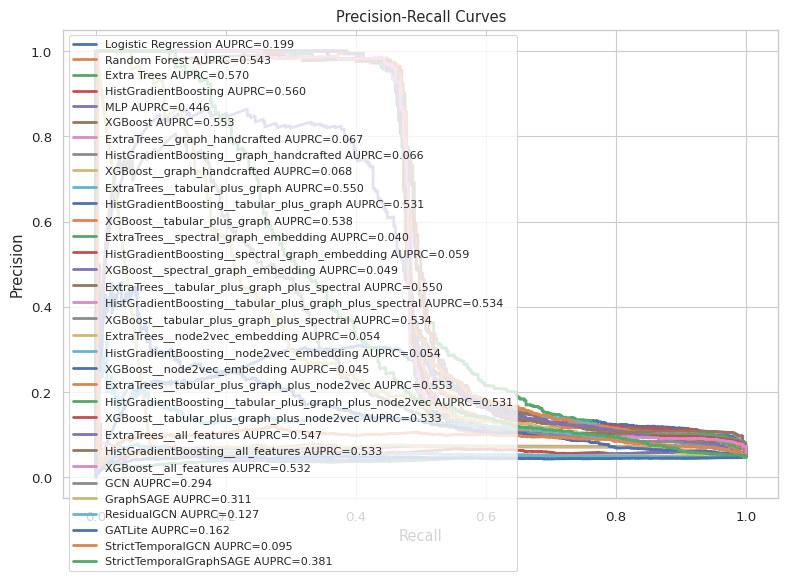

Saved figure: /kaggle/working/figures/fig_5_roc_curves.png


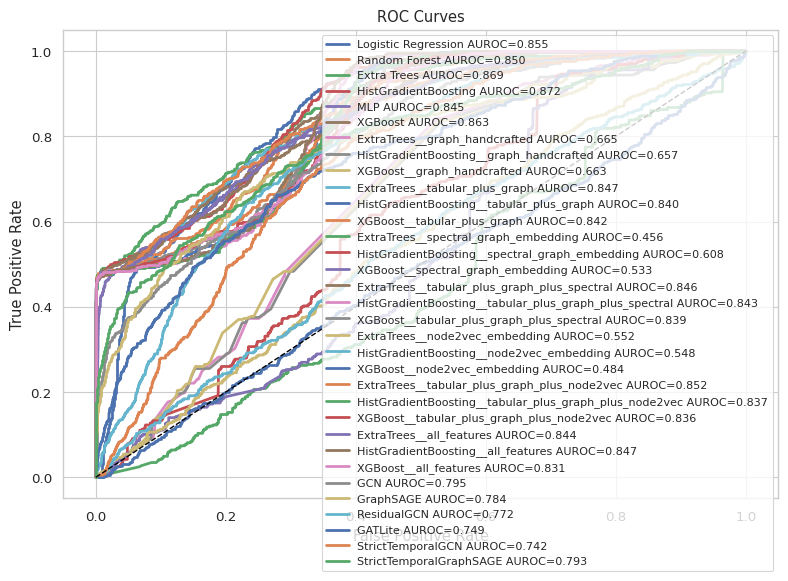

Saved figure: /kaggle/working/figures/fig_6_model_comparison.png


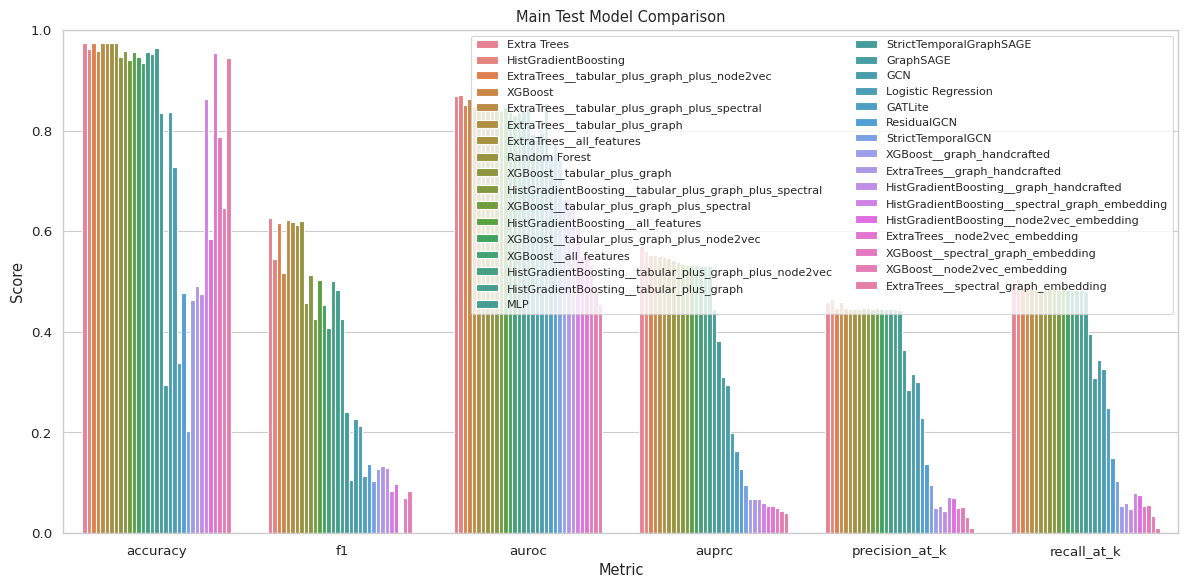

Saved table: /kaggle/working/tables/table_8_calibration_deciles.csv
Saved figure: /kaggle/working/figures/fig_7_calibration_curves.png


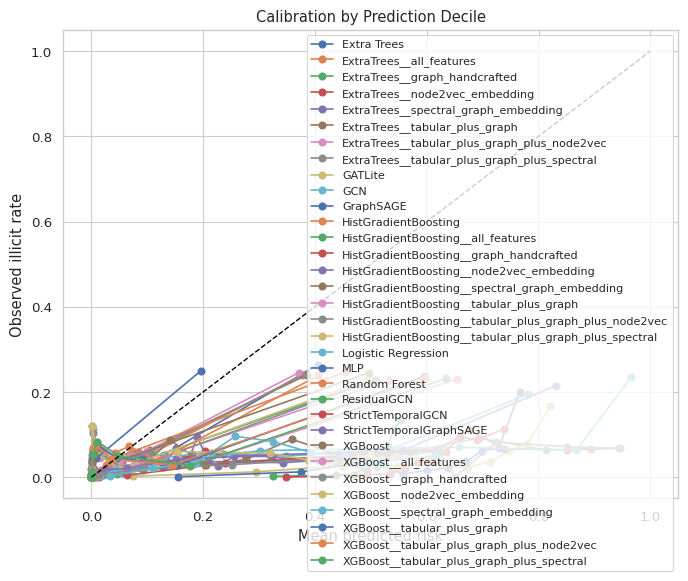

PosixPath('/kaggle/working/figures/fig_7_calibration_curves.png')

In [21]:
# ============================================================
# 11. Predictions and Publication Figures
# ============================================================

pred_out = nodes.loc[test_mask, ["txId", "node_idx", "time_step", "label", "class"]].copy().reset_index(drop=True)
for name, pred in model_predictions.items():
    pred_out[f"prob_illicit_{name.lower().replace(' ', '_')}"] = np.asarray(pred["test_prob"])
save_processed(pred_out, "predictions_main_test_set.csv")

plt.figure(figsize=(8, 6))
for name, pred in model_predictions.items():
    prob = np.asarray(pred["test_prob"])
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = safe_average_precision(y_test, prob)
    plt.plot(recall, precision, linewidth=2, label=f"{name} AUPRC={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend(fontsize=8)
save_figure("fig_4_precision_recall_curves.png")

plt.figure(figsize=(8, 6))
for name, pred in model_predictions.items():
    prob = np.asarray(pred["test_prob"])
    if len(np.unique(y_test)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, linewidth=2, label=f"{name} AUROC={auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8)
save_figure("fig_5_roc_curves.png")

plot_metrics = performance_wide.melt(
    id_vars=["model", "family"],
    value_vars=["accuracy", "f1", "auroc", "auprc", "precision_at_k", "recall_at_k"],
    var_name="metric",
    value_name="value",
)
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_metrics, x="metric", y="value", hue="model")
plt.ylim(0, 1)
plt.title("Main Test Model Comparison")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(fontsize=8, ncol=2)
save_figure("fig_6_model_comparison.png")

cal_rows = []
for name, pred in model_predictions.items():
    tmp = pd.DataFrame({"y": y_test, "prob": np.asarray(pred["test_prob"])})
    tmp["bin"] = pd.qcut(tmp["prob"], q=min(10, tmp["prob"].nunique()), duplicates="drop")
    g = tmp.groupby("bin", observed=True).agg(mean_prob=("prob", "mean"), observed_rate=("y", "mean"), n=("y", "size")).reset_index()
    g["model"] = name
    cal_rows.append(g)
calibration = pd.concat(cal_rows, ignore_index=True)
save_table(calibration.drop(columns=["bin"], errors="ignore"), "table_8_calibration_deciles.csv")

plt.figure(figsize=(7, 6))
for name, g in calibration.groupby("model"):
    plt.plot(g["mean_prob"], g["observed_rate"], marker="o", label=name)
plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)
plt.xlabel("Mean predicted risk")
plt.ylabel("Observed illicit rate")
plt.title("Calibration by Prediction Decile")
plt.legend(fontsize=8)
save_figure("fig_7_calibration_curves.png")

## Explainability

The notebook produces feature importance for the best tabular model and an example high-risk transaction neighborhood for analyst-facing interpretation. Because Elliptic feature names are anonymized, the paper should interpret feature concentration cautiously.

Best explainable model: Extra Trees test AUPRC: 0.5698956987932415
Saved table: /kaggle/working/tables/table_9_feature_importance.csv
Saved figure: /kaggle/working/figures/fig_8_feature_importance.png


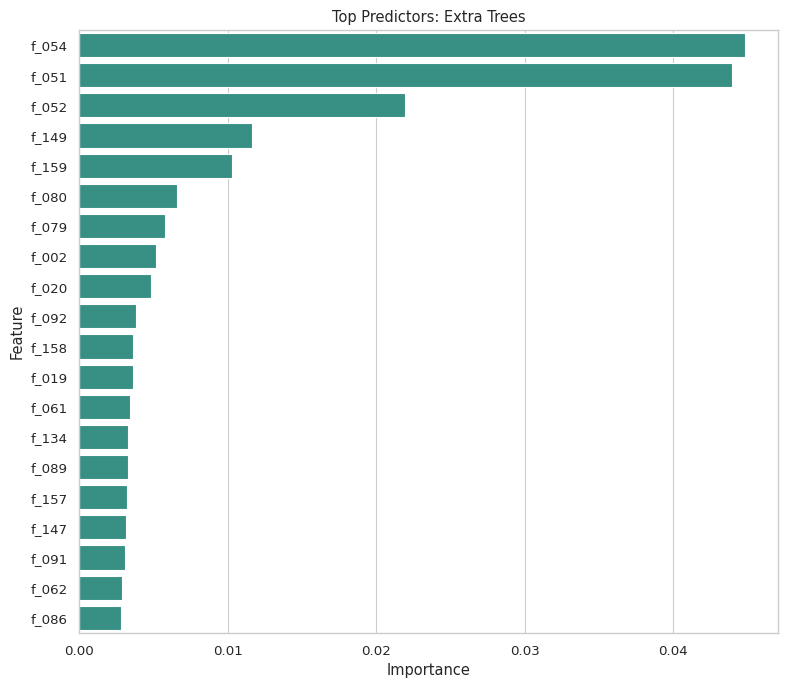

In [22]:
# ============================================================
# 12. Feature Importance
# ============================================================

# Select the best interpretable sklearn model across original tabular and advanced ablation models.
explainable_candidates = []
for name, pred in model_predictions.items():
    model_obj = None
    cols = None
    Xte = None
    if name in trained_models:
        model_obj = trained_models[name]
        cols = feature_cols
        Xte = X_test
    elif 'advanced_trained_models' in globals() and name in advanced_trained_models:
        model_obj = advanced_trained_models[name]
        fs = pred.get('feature_set')
        cols = feature_set_matrices[fs]['columns']
        Xte = feature_set_matrices[fs]['X_test']
    if model_obj is not None and (hasattr(model_obj, 'feature_importances_') or hasattr(model_obj, 'coef_')):
        explainable_candidates.append({
            'model': name,
            'model_obj': model_obj,
            'columns': cols,
            'X_test_model': Xte,
            'val_auprc': safe_average_precision(y_val, pred['val_prob']),
            'test_auprc': safe_average_precision(y_test, pred['test_prob']),
        })

if not explainable_candidates:
    print('No explainable sklearn candidate found for feature importance.')
else:
    best_exp = sorted(explainable_candidates, key=lambda d: d['val_auprc'], reverse=True)[0]
    best_tabular = best_exp['model']
    best_model = best_exp['model_obj']
    explain_cols = best_exp['columns']
    explain_X_test = best_exp['X_test_model']
    print('Best explainable model:', best_tabular, 'test AUPRC:', best_exp['test_auprc'])

    rows = []
    if hasattr(best_model, 'feature_importances_'):
        for f, v in zip(explain_cols, best_model.feature_importances_):
            rows.append({'model': best_tabular, 'feature': f, 'importance_type': 'model_builtin', 'importance': float(v)})
    elif hasattr(best_model, 'coef_'):
        for f, v in zip(explain_cols, np.ravel(best_model.coef_)):
            rows.append({'model': best_tabular, 'feature': f, 'importance_type': 'absolute_coefficient', 'importance': float(abs(v))})

    rng = np.random.default_rng(RANDOM_SEED)
    perm_n = min(MAX_PERMUTATION_ROWS, len(y_test))
    perm_idx = rng.choice(np.arange(len(y_test)), size=perm_n, replace=False)
    try:
        perm = permutation_importance(
            best_model, explain_X_test[perm_idx], y_test[perm_idx],
            scoring='average_precision',
            n_repeats=5 if SAMPLE_MODE else 10,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )
        for f, m, s in zip(explain_cols, perm.importances_mean, perm.importances_std):
            rows.append({'model': best_tabular, 'feature': f, 'importance_type': 'permutation_auprc_drop', 'importance': float(m), 'importance_std': float(s)})
    except Exception as e:
        print('Permutation importance failed:', e)

    importance = pd.DataFrame(rows)
    if len(importance):
        save_table(importance.sort_values('importance', ascending=False), 'table_9_feature_importance.csv')
        top = importance[importance['importance_type'] == 'permutation_auprc_drop'].sort_values('importance', ascending=False).head(20)
        if len(top) == 0:
            top = importance.sort_values('importance', ascending=False).head(20)
        plt.figure(figsize=(8, 7))
        sns.barplot(data=top, y='feature', x='importance', color='#2A9D8F')
        plt.title(f'Top Predictors: {best_tabular}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        save_figure('fig_8_feature_importance.png')


Best overall model: Extra Trees
txId                     71451667
time_step                      42
class                           1
label                           1
risk_score_best_model    0.993746
Name: 167963, dtype: object
Saved figure: /kaggle/working/figures/fig_9_high_risk_transaction_neighborhood.png


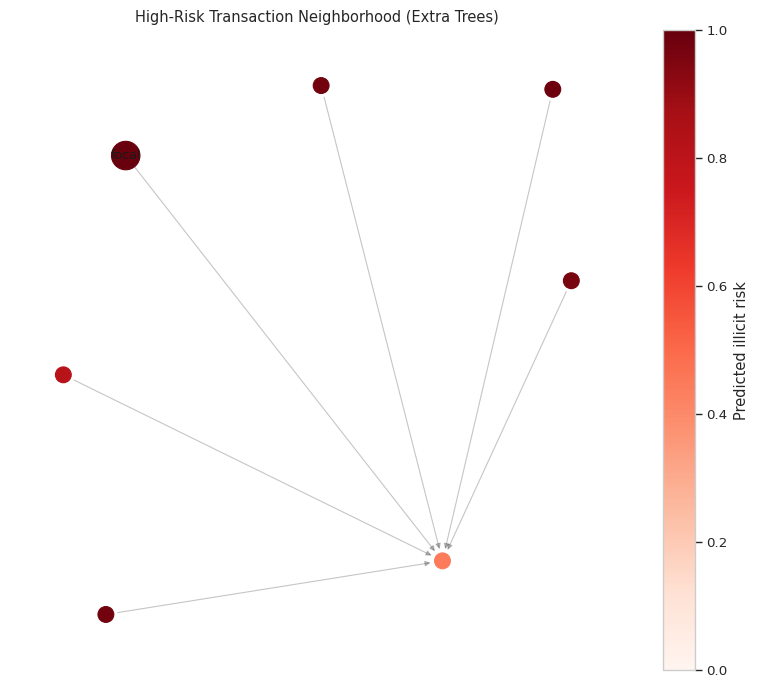

In [23]:
# ============================================================
# 13. High-Risk Transaction Neighborhood
# ============================================================

def get_all_probabilities_for_model(model_name):
    pred = model_predictions[model_name]
    if 'all_prob' in pred:
        return pred['all_prob']
    if model_name in trained_models:
        return trained_models[model_name].predict_proba(X_all_scaled)[:, 1]
    if 'advanced_trained_models' in globals() and model_name in advanced_trained_models:
        fs = pred.get('feature_set')
        X_all_model = feature_set_matrices[fs]['X_all']
        return advanced_trained_models[model_name].predict_proba(X_all_model)[:, 1]
    raise KeyError(f'Cannot produce all-node probabilities for {model_name}')

best_overall = max(model_predictions.keys(), key=lambda n: safe_average_precision(y_test, model_predictions[n]['test_prob']))
print('Best overall model:', best_overall)

all_probs = get_all_probabilities_for_model(best_overall)
nodes['risk_score_best_model'] = all_probs

test_idx = np.where(test_mask)[0]
illicit_test_idx = test_idx[y_all[test_idx] == 1]
focal_idx = illicit_test_idx[np.argmax(all_probs[illicit_test_idx])] if len(illicit_test_idx) else test_idx[np.argmax(all_probs[test_idx])]
print(nodes.loc[focal_idx, ['txId', 'time_step', 'class', 'label', 'risk_score_best_model']])

if HAS_NETWORKX:
    incident = edges[(edges['src'] == focal_idx) | (edges['dst'] == focal_idx)]
    neigh = set(incident['src'].tolist()) | set(incident['dst'].tolist()) | {int(focal_idx)}
    if len(neigh) < 15:
        incident2 = edges[(edges['src'].isin(neigh)) | (edges['dst'].isin(neigh))]
        neigh |= set(incident2['src'].tolist()) | set(incident2['dst'].tolist())
    if len(neigh) > 45:
        top = nodes.loc[list(neigh), 'risk_score_best_model'].sort_values(ascending=False).head(44).index.tolist()
        keep = set(top) | {int(focal_idx)}
    else:
        keep = neigh

    sub_edges = edges[edges['src'].isin(keep) & edges['dst'].isin(keep)]
    G = nx.DiGraph()
    for n in keep:
        G.add_node(int(n), risk=float(nodes.loc[n, 'risk_score_best_model']))
    for _, e in sub_edges.iterrows():
        G.add_edge(int(e['src']), int(e['dst']))

    if G.number_of_nodes() > 0:
        pos_layout = nx.spring_layout(G, seed=RANDOM_SEED, k=0.7)
        colors = [G.nodes[n]['risk'] for n in G.nodes()]
        sizes = [420 if n == focal_idx else 130 for n in G.nodes()]
        plt.figure(figsize=(8, 7))
        nx.draw_networkx_edges(G, pos_layout, alpha=0.25, arrows=True, width=0.8, arrowsize=8)
        sc = nx.draw_networkx_nodes(G, pos_layout, node_color=colors, node_size=sizes, cmap='Reds', vmin=0, vmax=1)
        nx.draw_networkx_labels(G, pos_layout, labels={int(focal_idx): 'focal'}, font_size=9)
        plt.colorbar(sc, label='Predicted illicit risk')
        plt.title(f'High-Risk Transaction Neighborhood ({best_overall})')
        plt.axis('off')
        save_figure('fig_9_high_risk_transaction_neighborhood.png')
else:
    print('NetworkX unavailable. Skipping graph visualization.')


## Diagnostic Interpretation: When Graph AI Does Not Win

Top-tier papers should explain negative or mixed results. This diagnostic table compares the best transaction-feature-only model, best feature-augmented model, and best graph neural model.

In [24]:
# ============================================================
# 13B. Graph Underperformance Diagnostics
# ============================================================

ranking = pd.DataFrame([
    {"model": name, "family": pred.get("family"), "feature_set": pred.get("feature_set", "model_native"), **compute_metrics(y_test, pred["test_prob"], k_frac=PRECISION_RECALL_AT_K_FRAC)}
    for name, pred in model_predictions.items()
]).sort_values("auprc", ascending=False)

best_by_family = ranking.sort_values("auprc", ascending=False).groupby("family", as_index=False).first()
save_table(ranking, "table_19_all_model_ranking_diagnostics.csv")
save_table(best_by_family, "table_20_best_model_by_family.csv")

best_graph = ranking[ranking["family"] == "graph_ai"].head(1)
best_non_graph = ranking[ranking["family"] != "graph_ai"].head(1)
graph_gap = float(best_non_graph.iloc[0]["auprc"] - best_graph.iloc[0]["auprc"]) if len(best_graph) and len(best_non_graph) else np.nan

diagnostic_notes = pd.DataFrame([
    {"diagnostic": "best_non_graph_minus_best_graph_auprc", "value": graph_gap, "interpretation": "Positive values indicate that current GNNs did not dominate stronger non-graph or feature-augmented models."},
    {"diagnostic": "test_illicit_rate", "value": float(y_test.mean()), "interpretation": "Low base rate makes accuracy less informative and increases the importance of AUPRC and Recall@K."},
    {"diagnostic": "edge_direction_symmetrized_for_gnn", "value": 1.0, "interpretation": "GCN/GraphSAGE used symmetrized edges; AML money-flow direction may require directed models."},
    {"diagnostic": "unknown_nodes_retained_in_graph", "value": float((nodes["label"] == -1).mean()), "interpretation": "Unknown nodes support message passing but can also introduce noisy neighborhoods."},
])
save_table(diagnostic_notes, "table_21_graph_underperformance_diagnostics.csv")

display(best_by_family)
display(diagnostic_notes)

Saved table: /kaggle/working/tables/table_19_all_model_ranking_diagnostics.csv
Saved table: /kaggle/working/tables/table_20_best_model_by_family.csv
Saved table: /kaggle/working/tables/table_21_graph_underperformance_diagnostics.csv


,family,model,feature_set,accuracy,precision,recall,f1,auroc,auprc,brier,precision_at_k,recall_at_k,k
0,feature_ablation,ExtraTrees__tabular_plus_graph_plus_node2vec,tabular_plus_graph_plus_node2vec,0.973872,0.958549,0.453431,0.615641,0.851793,0.553424,0.027905,0.446953,0.485294,443
1,graph_ai,GraphSAGE,model_native,0.294311,0.056173,0.904412,0.105776,0.783568,0.310828,0.336536,0.284424,0.308824,443
2,strict_temporal_graph_ai,StrictTemporalGraphSAGE,model_native,0.835878,0.152565,0.561275,0.239916,0.792832,0.380891,0.110286,0.363431,0.394608,443
3,tabular_ml,Extra Trees,model_native,0.973872,0.923445,0.473039,0.625608,0.869470,0.569896,0.028745,0.458239,0.497549,443


,diagnostic,value,interpretation
0,best_non_graph_minus_best_graph_auprc,0.259068,Positive values indicate that current GNNs did...
1,test_illicit_rate,0.046149,Low base rate makes accuracy less informative ...
2,edge_direction_symmetrized_for_gnn,1.000000,GCN/GraphSAGE used symmetrized edges; AML mone...
3,unknown_nodes_retained_in_graph,0.771486,Unknown nodes support message passing but can ...


## Study 2: Elliptic2 External Subgraph-Level Validation

Elliptic2 changes the problem from transaction-node classification to **subgraph-level laundering-shape classification**. This section uses Elliptic2 as an external validation/extension benchmark. It is designed to be Kaggle-Free aware: it avoids loading the huge background graph in full and focuses on the labeled subgraph files.

The code is schema-tolerant because Kaggle mirrors can preserve column names differently. It first inspects the files, then infers node, edge, component, and label columns.

In [25]:
# ============================================================
# 14A. Resolve and Inspect Elliptic2 Files
# ============================================================

ELLIPTIC2_REQUIRED = {
    "background_edges": "background_edges.csv",
    "background_nodes": "background_nodes.csv",
    "connected_components": "connected_components.csv",
    "edges": "edges.csv",
    "nodes": "nodes.csv",
}


def resolve_elliptic2_paths():
    preferred_dirs = [
        Path("/kaggle/input/datasets/organizations/ellipticco/elliptic2-data-set"),
        Path("/kaggle/input/elliptic2-data-set"),
        Path("/kaggle/input/elliptic2"),
    ]
    candidate_dirs = [d for d in preferred_dirs if d.exists()]
    if INPUT_ROOT.exists():
        for f in INPUT_ROOT.rglob("connected_components.csv"):
            candidate_dirs.append(f.parent)
    seen, unique_dirs = set(), []
    for d in candidate_dirs:
        key = str(d.resolve()) if d.exists() else str(d)
        if key not in seen:
            seen.add(key)
            unique_dirs.append(d)
    for d in unique_dirs:
        paths = {k: d / v for k, v in ELLIPTIC2_REQUIRED.items()}
        if all(paths[k].exists() for k in ["connected_components", "edges", "nodes"]):
            return d, paths
    return None, {}


ELLIPTIC2_DIR, ELLIPTIC2_PATHS = resolve_elliptic2_paths()
print("Elliptic2 resolved folder:", ELLIPTIC2_DIR)

ell2_schema_rows = []
if ELLIPTIC2_DIR is not None:
    for name, path in ELLIPTIC2_PATHS.items():
        exists = path.exists()
        size = path.stat().st_size if exists else np.nan
        cols = []
        preview = ""
        if exists:
            try:
                head = pd.read_csv(path, nrows=5)
                cols = list(head.columns)
                preview = head.head(2).to_json(orient="records")
            except Exception as e:
                preview = f"Could not preview: {repr(e)}"
        ell2_schema_rows.append({
            "file_key": name,
            "path": str(path),
            "exists": exists,
            "size_bytes": size,
            "columns": str(cols),
            "preview": preview[:500],
        })
else:
    ell2_schema_rows.append({
        "file_key": "elliptic2",
        "path": "",
        "exists": False,
        "size_bytes": np.nan,
        "columns": "",
        "preview": "Elliptic2 files not attached. Study 2 skipped.",
    })

ell2_schema = pd.DataFrame(ell2_schema_rows)
save_table(ell2_schema, "table_22_elliptic2_schema_inspection.csv")
ell2_schema

Elliptic2 resolved folder: /kaggle/input/datasets/organizations/ellipticco/elliptic2-data-set
Saved table: /kaggle/working/tables/table_22_elliptic2_schema_inspection.csv


,file_key,path,exists,size_bytes,columns,preview
0,background_edges,/kaggle/input/datasets/organizations/ellipticc...,True,82877432755,"['clId1', 'clId2', 'txId', 'feat#1', 'feat#2',...","[{""clId1"":563997622,""clId2"":284528470,""txId"":5..."
1,background_nodes,/kaggle/input/datasets/organizations/ellipticc...,True,5347932879,"['clId', 'feat#1', 'feat#2', 'feat#3', 'feat#4...","[{""clId"":284528470,""feat#1"":75,""feat#2"":68,""fe..."
2,connected_components,/kaggle/input/datasets/organizations/ellipticc...,True,1610070,"['ccId', 'ccLabel']","[{""ccId"":0,""ccLabel"":""licit""},{""ccId"":1,""ccLab..."
3,edges,/kaggle/input/datasets/organizations/ellipticc...,True,11356690,"['clId1', 'clId2', 'txId']","[{""clId1"":753456251,""clId2"":753456254,""txId"":2..."
4,nodes,/kaggle/input/datasets/organizations/ellipticc...,True,7470115,"['clId', 'ccId']","[{""clId"":515498410,""ccId"":41121},{""clId"":63036..."


In [26]:
# ============================================================
# 14B. Elliptic2 Schema Inference Helpers
# ============================================================

def clean_colnames(df):
    df = df.copy()
    df.columns = [str(c).strip().lower().replace(" ", "_") for c in df.columns]
    return df


def first_matching_col(cols, include_terms, exclude_terms=()):
    for c in cols:
        cl = str(c).lower()
        if any(t in cl for t in include_terms) and not any(t in cl for t in exclude_terms):
            return c
    return None


def infer_node_col(df):
    cols = list(df.columns)
    for terms in [["node_id"], ["node"], ["txid"], ["tx_id"], ["cluster"], ["address"], ["id"]]:
        c = first_matching_col(cols, terms, exclude_terms=("component", "subgraph", "label", "class", "target"))
        if c is not None:
            return c
    return cols[0]


def infer_component_col(df):
    cols = list(df.columns)
    for terms in [["component"], ["connected"], ["subgraph"], ["sub_graph"], ["graph_id"], ["cc"], ["community"]]:
        c = first_matching_col(cols, terms, exclude_terms=("label", "class", "target"))
        if c is not None:
            return c
    return None


def infer_label_col(df, avoid_cols=()):
    avoid_cols = set(avoid_cols)
    candidates = []
    for c in df.columns:
        if c in avoid_cols:
            continue
        cl = str(c).lower()
        if any(t in cl for t in ["label", "class", "target", "y", "licit", "illicit", "suspicious"]):
            candidates.append(c)
    for c in list(df.columns):
        if c in avoid_cols or c in candidates:
            continue
        s = df[c].dropna().astype(str).str.lower().head(5000)
        vals = set(s.unique())
        if len(vals) <= 8 and any(v in vals for v in ["licit", "illicit", "suspicious", "1", "0", "2"]):
            candidates.append(c)
    return candidates[0] if candidates else None


def infer_edge_cols(df):
    cols = list(df.columns)
    src_col = None
    dst_col = None
    for terms in [["src"], ["source"], ["from"], ["txid1"], ["node1"], ["u"]]:
        src_col = first_matching_col(cols, terms)
        if src_col is not None:
            break
    for terms in [["dst"], ["target"], ["to"], ["txid2"], ["node2"], ["v"]]:
        dst_col = first_matching_col(cols, terms)
        if dst_col is not None:
            break
    if src_col is None or dst_col is None:
        src_col, dst_col = cols[0], cols[1]
    return src_col, dst_col


def map_elliptic2_label_value(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().lower()
    if s in {"1", "true", "illicit", "suspicious", "dirty", "laundering", "ml", "positive"}:
        return 1
    if s in {"0", "2", "false", "licit", "clean", "normal", "negative"}:
        return 0
    try:
        val = float(s)
        if val == 1:
            return 1
        if val in (0, 2):
            return 0
    except Exception:
        pass
    return np.nan


def stratified_sample_frame(df, label_col, max_rows, seed=RANDOM_SEED):
    if max_rows is None or len(df) <= max_rows:
        return df.copy()
    parts = []
    for label, g in df.groupby(label_col, dropna=False):
        take = max(1, int(round(max_rows * len(g) / len(df))))
        parts.append(g.sample(n=min(take, len(g)), random_state=seed))
    out = pd.concat(parts, ignore_index=True)
    if len(out) > max_rows:
        out = out.sample(n=max_rows, random_state=seed)
    return out.reset_index(drop=True)

In [27]:
# ============================================================
# 14C. Build Elliptic2 Subgraph-Level Feature Table
# ============================================================

ell2_ready = False
ell2_mode = "skipped"

if RUN_ELLIPTIC2_EXTERNAL and ELLIPTIC2_DIR is not None:
    nrows_edges = ELLIPTIC2_MAX_EDGE_ROWS if ELLIPTIC2_SAMPLE_MODE else None
    print("Reading Elliptic2 labeled nodes/components/edges...")

    # nodes.csv is small and maps cluster/node IDs to connected component IDs.
    # connected_components.csv is small and maps component IDs to licit/suspicious labels.
    ell2_nodes = clean_colnames(pd.read_csv(ELLIPTIC2_PATHS["nodes"]))
    ell2_edges = clean_colnames(pd.read_csv(ELLIPTIC2_PATHS["edges"], nrows=nrows_edges))
    ell2_cc = clean_colnames(pd.read_csv(ELLIPTIC2_PATHS["connected_components"]))

    print("nodes:", ell2_nodes.shape, "edges:", ell2_edges.shape, "connected_components:", ell2_cc.shape)

    node_col_nodes = infer_node_col(ell2_nodes)
    comp_col_nodes = infer_component_col(ell2_nodes)
    node_col_cc = infer_node_col(ell2_cc)
    comp_col_cc = infer_component_col(ell2_cc)
    label_col_cc = infer_label_col(ell2_cc, avoid_cols={node_col_cc, comp_col_cc})
    label_col_nodes = infer_label_col(ell2_nodes, avoid_cols={node_col_nodes, comp_col_nodes})

    # Elliptic2 Kaggle schema normally has nodes.csv: clId, ccId and
    # connected_components.csv: ccId, ccLabel. Prefer that explicit mapping.
    if comp_col_nodes is None:
        raise ValueError("Could not infer component column in Elliptic2 nodes.csv. Inspect table_22_elliptic2_schema_inspection.csv.")

    membership = ell2_nodes[[comp_col_nodes, node_col_nodes]].copy()
    membership.columns = ["subgraph_id", "node_id"]
    membership["node_id"] = membership["node_id"].astype(str)
    membership["subgraph_id"] = membership["subgraph_id"].astype(str)
    label_source = "nodes_membership_plus_connected_components_labels"

    if label_col_cc is not None and comp_col_cc is not None:
        labels = ell2_cc[[comp_col_cc, label_col_cc]].copy()
        labels.columns = ["subgraph_id", "raw_label"]
        labels["subgraph_id"] = labels["subgraph_id"].astype(str)
        labels["label"] = labels["raw_label"].map(map_elliptic2_label_value)
        labels = labels.dropna(subset=["label"])[["subgraph_id", "label"]].drop_duplicates("subgraph_id")
    elif label_col_nodes is not None:
        node_labels = ell2_nodes[[node_col_nodes, label_col_nodes]].copy()
        node_labels.columns = ["node_id", "raw_label"]
        node_labels["node_id"] = node_labels["node_id"].astype(str)
        node_labels["label"] = node_labels["raw_label"].map(map_elliptic2_label_value)
        labels = membership[["subgraph_id", "node_id"]].merge(
            node_labels[["node_id", "label"]].dropna(subset=["label"]), on="node_id", how="left"
        )
        labels = labels.dropna(subset=["label"]).groupby("subgraph_id")["label"].agg(lambda s: int(round(s.mean()))).reset_index()
    else:
        labels = pd.DataFrame(columns=["subgraph_id", "label"])

    node_counts = membership.groupby("subgraph_id")["node_id"].nunique().rename("node_count").reset_index()
    ell2_subgraphs = node_counts.merge(labels, on="subgraph_id", how="left")
    ell2_subgraphs["label"] = ell2_subgraphs["label"].astype("float")
    ell2_labeled_ids = ell2_subgraphs.dropna(subset=["label"]).copy()
    ell2_labeled_ids["label"] = ell2_labeled_ids["label"].astype(int)
    ell2_labeled_ids = ell2_labeled_ids[ell2_labeled_ids["label"].isin([0, 1])].copy()

    # Sample labeled subgraphs before chunk-reading background_nodes.csv.
    ell2_labeled_ids = stratified_sample_frame(ell2_labeled_ids, "label", ELLIPTIC2_MAX_SUBGRAPHS, RANDOM_SEED)
    selected_subgraph_ids = set(ell2_labeled_ids["subgraph_id"].astype(str))
    selected_membership = membership[membership["subgraph_id"].isin(selected_subgraph_ids)].copy()
    selected_node_ids = set(selected_membership["node_id"].astype(str))
    print("Selected Elliptic2 subgraphs:", len(selected_subgraph_ids), "selected nodes:", len(selected_node_ids), "positive rate:", ell2_labeled_ids["label"].mean())

    # Subgraph edge structure from the labeled edges.csv file.
    src_edge_col, dst_edge_col = infer_edge_cols(ell2_edges)
    ell2_edges[src_edge_col] = ell2_edges[src_edge_col].astype(str)
    ell2_edges[dst_edge_col] = ell2_edges[dst_edge_col].astype(str)
    node_to_comp = selected_membership.drop_duplicates("node_id").set_index("node_id")["subgraph_id"]
    edge_comp = ell2_edges[[src_edge_col, dst_edge_col]].copy()
    edge_comp.columns = ["src", "dst"]
    edge_comp["src_comp"] = edge_comp["src"].map(node_to_comp)
    edge_comp["dst_comp"] = edge_comp["dst"].map(node_to_comp)
    edge_comp = edge_comp.dropna(subset=["src_comp", "dst_comp"])
    edge_comp = edge_comp[edge_comp["src_comp"] == edge_comp["dst_comp"]].copy()
    edge_comp["subgraph_id"] = edge_comp["src_comp"].astype(str)

    edge_features = pd.DataFrame({"subgraph_id": list(selected_subgraph_ids)})
    if len(edge_comp) > 0:
        edge_counts = edge_comp.groupby("subgraph_id").size().rename("edge_count").reset_index()
        out_deg = edge_comp.groupby(["subgraph_id", "src"]).size().rename("out_degree").reset_index()
        in_deg = edge_comp.groupby(["subgraph_id", "dst"]).size().rename("in_degree").reset_index()
        edge_features = edge_features.merge(edge_counts, on="subgraph_id", how="left")
        out_stats = out_deg.groupby("subgraph_id")["out_degree"].agg(["mean", "max", "std"]).reset_index()
        out_stats.columns = ["subgraph_id", "out_degree_mean", "out_degree_max", "out_degree_std"]
        in_stats = in_deg.groupby("subgraph_id")["in_degree"].agg(["mean", "max", "std"]).reset_index()
        in_stats.columns = ["subgraph_id", "in_degree_mean", "in_degree_max", "in_degree_std"]
        edge_features = edge_features.merge(out_stats, on="subgraph_id", how="left").merge(in_stats, on="subgraph_id", how="left")
    edge_features["edge_count"] = edge_features.get("edge_count", 0)
    edge_features = edge_features.fillna(0)

    # Rich background node feature extraction. background_nodes.csv is about 5GB,
    # so we stream raw CSV chunks, keep only selected cluster IDs, and aggregate
    # exactly after concatenating the retained rows. This avoids the 82GB
    # background_edges.csv file while still using Elliptic2's high-signal features.
    bg_path = ELLIPTIC2_PATHS.get("background_nodes")
    bg_feature_aggs = pd.DataFrame({"subgraph_id": list(selected_subgraph_ids)})
    bg_rows_kept = 0
    bg_feature_cols_used = []

    if bg_path is not None and bg_path.exists() and len(selected_node_ids) > 0:
        print("Chunk-reading background_nodes.csv for rich node features...")
        raw_header = pd.read_csv(bg_path, nrows=0)
        clean_header = clean_colnames(raw_header)
        raw_cols = list(raw_header.columns)
        clean_cols = list(clean_header.columns)
        raw_to_clean = dict(zip(raw_cols, clean_cols))
        clean_to_raw = {}
        for raw_col, clean_col in raw_to_clean.items():
            clean_to_raw.setdefault(clean_col, raw_col)

        bg_node_col = infer_node_col(clean_header)
        if bg_node_col not in clean_to_raw:
            raise ValueError("Could not map the inferred Elliptic2 background node ID column back to the raw CSV header.")
        bg_node_raw_col = clean_to_raw[bg_node_col]

        leakage_terms = ("id", "component", "subgraph", "label", "class", "target", "licit", "illicit", "cc")
        candidate_features = [
            c for c in clean_cols
            if c != bg_node_col and not any(term in c for term in leakage_terms)
        ]
        preferred_features = [c for c in candidate_features if c.startswith("feat") or "feature" in c or c.startswith("f")]
        if len(preferred_features) < min(4, len(candidate_features)):
            preferred_features = candidate_features
        bg_feature_cols = preferred_features[:ELLIPTIC2_MAX_BACKGROUND_FEATURES]
        bg_feature_raw_cols = [clean_to_raw[c] for c in bg_feature_cols if c in clean_to_raw]
        bg_feature_cols_used = [raw_to_clean[c] for c in bg_feature_raw_cols]
        usecols_raw = [bg_node_raw_col] + bg_feature_raw_cols

        selected_bg_rows = []
        for chunk_i, chunk in enumerate(pd.read_csv(bg_path, usecols=usecols_raw, chunksize=ELLIPTIC2_BACKGROUND_NODE_CHUNKSIZE)):
            chunk = clean_colnames(chunk)
            if bg_node_col not in chunk.columns:
                raise ValueError(f"Inferred background node column {bg_node_col!r} was not present after chunk normalization.")
            chunk[bg_node_col] = chunk[bg_node_col].astype(str)
            chunk = chunk[chunk[bg_node_col].isin(selected_node_ids)]
            if len(chunk) == 0:
                continue
            bg_rows_kept += len(chunk)
            chunk = chunk.merge(
                selected_membership[["node_id", "subgraph_id"]],
                left_on=bg_node_col,
                right_on="node_id",
                how="left",
            )
            numeric_cols = [c for c in bg_feature_cols_used if c in chunk.columns]
            for c in numeric_cols:
                chunk[c] = pd.to_numeric(chunk[c], errors="coerce")
            selected_bg_rows.append(chunk[["subgraph_id"] + numeric_cols].copy())
            if chunk_i % 10 == 0:
                print("  processed chunk", chunk_i, "kept rows so far", bg_rows_kept)

        if len(selected_bg_rows) > 0:
            bg_selected = pd.concat(selected_bg_rows, ignore_index=True)
            numeric_cols = [c for c in bg_feature_cols_used if c in bg_selected.columns]
            agg_dict = {}
            for c in numeric_cols:
                agg_dict[f"bg_{c}_mean"] = (c, "mean")
                agg_dict[f"bg_{c}_std"] = (c, "std")
                agg_dict[f"bg_{c}_max"] = (c, "max")
                agg_dict[f"bg_{c}_min"] = (c, "min")
            if len(agg_dict) > 0:
                bg_feature_aggs = bg_selected.groupby("subgraph_id").agg(**agg_dict).reset_index()
        print("Background rows kept:", bg_rows_kept, "background feature columns used:", len(bg_feature_cols_used))
    else:
        print("background_nodes.csv unavailable or no selected nodes; using structure-only Elliptic2 features.")

    ell2_model = ell2_labeled_ids[["subgraph_id", "node_count", "label"]].copy()
    ell2_model = ell2_model.merge(edge_features, on="subgraph_id", how="left")
    ell2_model = ell2_model.merge(bg_feature_aggs, on="subgraph_id", how="left")
    ell2_model = ell2_model.fillna(0)
    ell2_model["density_directed"] = ell2_model["edge_count"] / (ell2_model["node_count"] * (ell2_model["node_count"] - 1) + 1.0)
    ell2_model["log_node_count"] = np.log1p(ell2_model["node_count"])
    ell2_model["log_edge_count"] = np.log1p(ell2_model["edge_count"])
    ell2_model["edge_node_ratio"] = ell2_model["edge_count"] / (ell2_model["node_count"] + 1.0)

    ell2_feature_cols = [c for c in ell2_model.select_dtypes(include=[np.number]).columns if c != "label"]
    ell2_model[ell2_feature_cols] = ell2_model[ell2_feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    ell2_ready = len(ell2_model) > 100 and ell2_model["label"].nunique() == 2
    ell2_mode = label_source + "+background_node_features"

    save_table(pd.DataFrame({
        "item": ["mode", "subgraphs", "features", "positive_rate", "selected_nodes", "background_rows_kept", "background_feature_columns_used", "edge_rows_loaded"],
        "value": [ell2_mode, len(ell2_model), len(ell2_feature_cols), ell2_model["label"].mean() if len(ell2_model) else np.nan, len(selected_node_ids), bg_rows_kept, len(bg_feature_cols_used), len(ell2_edges)],
    }), "table_23_elliptic2_sample_construction.csv")
    save_table(pd.DataFrame({"elliptic2_feature": ell2_feature_cols}), "table_23b_elliptic2_feature_dictionary.csv")
    save_processed(ell2_model, "elliptic2_subgraph_modeling_sample.parquet")
    print("Elliptic2 ready:", ell2_ready, "mode:", ell2_mode)
    print("Subgraphs:", len(ell2_model), "features:", len(ell2_feature_cols), "positive rate:", ell2_model["label"].mean() if len(ell2_model) else np.nan)
else:
    print("Elliptic2 external validation skipped. Attach Elliptic2 files and set RUN_ELLIPTIC2_EXTERNAL=True.")
    ell2_model = pd.DataFrame()
    ell2_feature_cols = []


Reading Elliptic2 labeled nodes/components/edges...
nodes: (444521, 2) edges: (367137, 3) connected_components: (121810, 2)
Selected Elliptic2 subgraphs: 121810 selected nodes: 444521 positive rate: 0.02268286675970774
Chunk-reading background_nodes.csv for rich node features...
  processed chunk 0 kept rows so far 10292
  processed chunk 10 kept rows so far 99474
  processed chunk 20 kept rows so far 170772
  processed chunk 30 kept rows so far 234949
  processed chunk 40 kept rows so far 297055
  processed chunk 50 kept rows so far 359819
  processed chunk 60 kept rows so far 417878
Background rows kept: 444521 background feature columns used: 32
Saved table: /kaggle/working/tables/table_23_elliptic2_sample_construction.csv
Saved table: /kaggle/working/tables/table_23b_elliptic2_feature_dictionary.csv
Saved data: /kaggle/working/processed_data/elliptic2_subgraph_modeling_sample.parquet
Elliptic2 ready: True mode: nodes_membership_plus_connected_components_labels+background_node_featu

Elliptic2 split: stratified_random train/val/test: (85267, 140) (18271, 140) (18272, 140)
Positive rates: 0.022681693973049363 0.02265885830003831 0.022712346760070053

Training Elliptic2_LogisticRegression
Elliptic2_LogisticRegression: AUPRC=0.1519, AUROC=0.8853, seconds=9.0

Training Elliptic2_RandomForest
Elliptic2_RandomForest: AUPRC=0.4940, AUROC=0.9226, seconds=39.1

Training Elliptic2_ExtraTrees
Elliptic2_ExtraTrees: AUPRC=0.4617, AUROC=0.9205, seconds=22.3

Training Elliptic2_HistGradientBoosting
Elliptic2_HistGradientBoosting: AUPRC=0.4668, AUROC=0.9287, seconds=3.9

Training Elliptic2_MLP
Elliptic2_MLP: AUPRC=0.4371, AUROC=0.9121, seconds=11.6

Training Elliptic2_XGBoost
Elliptic2_XGBoost: AUPRC=0.4675, AUROC=0.9256, seconds=3.8
Saved table: /kaggle/working/tables/table_24_elliptic2_external_performance_with_ci.csv
Saved table: /kaggle/working/tables/table_25_elliptic2_external_performance_wide.csv
Saved figure: /kaggle/working/figures/fig_10_elliptic2_precision_recall_curves

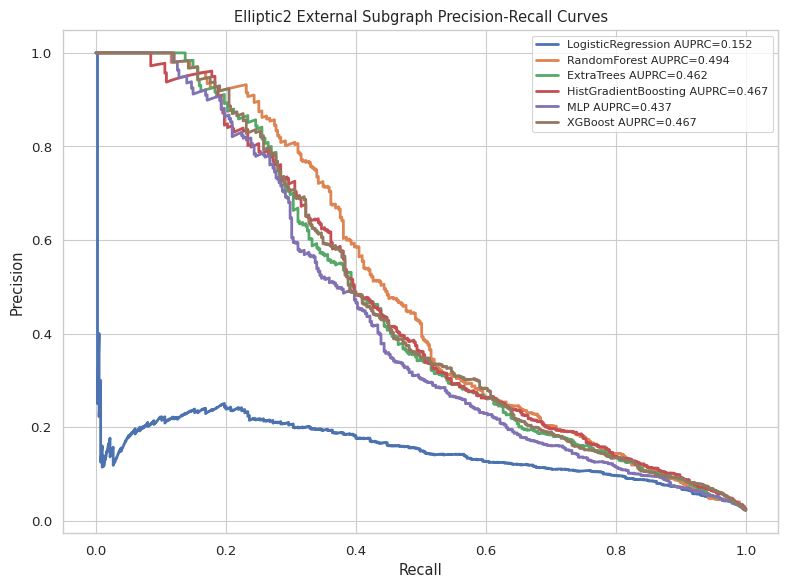

Saved figure: /kaggle/working/figures/fig_11_elliptic2_roc_curves.png


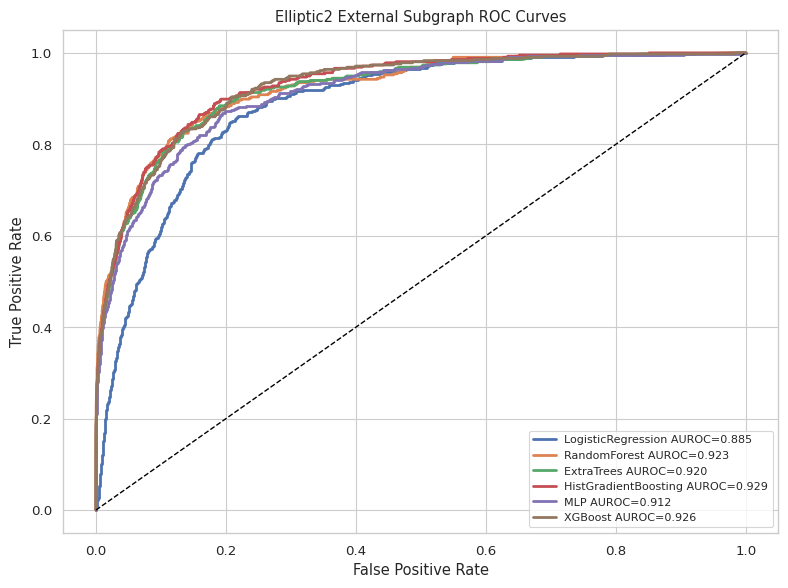

,model,accuracy,precision,recall,f1,auroc,auprc,brier,precision_at_k,recall_at_k,k
1,Elliptic2_RandomForest,0.981885,0.928571,0.219277,0.354776,0.922606,0.494042,0.015623,0.270241,0.595181,914
5,Elliptic2_XGBoost,0.858417,0.120545,0.831325,0.210558,0.925608,0.467452,0.090735,0.275711,0.607229,914
3,Elliptic2_HistGradientBoosting,0.863562,0.124910,0.833735,0.217268,0.928655,0.466812,0.084869,0.268053,0.590361,914
2,Elliptic2_ExtraTrees,0.981447,0.880000,0.212048,0.341748,0.920491,0.461680,0.016540,0.266958,0.587952,914
4,Elliptic2_MLP,0.981502,0.776978,0.260241,0.389892,0.912064,0.437074,0.016315,0.258206,0.568675,914
0,Elliptic2_LogisticRegression,0.794002,0.086849,0.848193,0.157565,0.885271,0.151936,0.144046,0.181619,0.400000,914


In [28]:
# ============================================================
# 14D. Elliptic2 External Subgraph Modeling
# ============================================================

ell2_predictions = {}
ell2_performance_ci = pd.DataFrame()
ell2_performance_wide = pd.DataFrame()

if ell2_ready:
    y2 = ell2_model["label"].to_numpy(dtype=int)
    X2_raw = ell2_model[ell2_feature_cols].to_numpy(dtype=np.float32)

    # Prefer temporal split if an obvious time/block column exists; otherwise stratified split.
    time_candidates = [c for c in ell2_feature_cols if any(t in c.lower() for t in ["time", "timestamp", "block", "height", "step"])]
    split2_type = "stratified_random"
    if len(time_candidates) > 0 and ell2_model[time_candidates[0]].nunique() > 5:
        tcol = time_candidates[0]
        order = ell2_model[tcol].rank(method="first").to_numpy()
        q1, q2 = np.quantile(order, [0.70, 0.85])
        tr2 = order <= q1
        va2 = (order > q1) & (order <= q2)
        te2 = order > q2
        if len(np.unique(y2[tr2])) == 2 and len(np.unique(y2[va2])) == 2 and len(np.unique(y2[te2])) == 2:
            split2_type = f"temporal_by_{tcol}"
        else:
            tr2 = va2 = te2 = None
    else:
        tr2 = va2 = te2 = None

    if tr2 is None:
        idx = np.arange(len(y2))
        s1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
        tr_pos, temp_pos = next(s1.split(idx, y2))
        tr_idx, temp_idx = idx[tr_pos], idx[temp_pos]
        s2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
        va_pos, te_pos = next(s2.split(temp_idx, y2[temp_idx]))
        va_idx, te_idx = temp_idx[va_pos], temp_idx[te_pos]
        tr2 = np.zeros(len(y2), dtype=bool); tr2[tr_idx] = True
        va2 = np.zeros(len(y2), dtype=bool); va2[va_idx] = True
        te2 = np.zeros(len(y2), dtype=bool); te2[te_idx] = True

    sc2 = StandardScaler()
    X2 = sc2.fit_transform(X2_raw[tr2]).astype(np.float32)
    X2_all = sc2.transform(X2_raw).astype(np.float32)
    X2_train, y2_train = X2_all[tr2], y2[tr2]
    X2_val, y2_val = X2_all[va2], y2[va2]
    X2_test, y2_test = X2_all[te2], y2[te2]
    print("Elliptic2 split:", split2_type, "train/val/test:", X2_train.shape, X2_val.shape, X2_test.shape)
    print("Positive rates:", y2_train.mean(), y2_val.mean(), y2_test.mean())

    sw2 = compute_sample_weight(class_weight="balanced", y=y2_train)
    pos2 = max(1, int((y2_train == 1).sum()))
    neg2 = max(1, int((y2_train == 0).sum()))
    ell2_models = {
        "Elliptic2_LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
        "Elliptic2_RandomForest": RandomForestClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_SEED),
        "Elliptic2_ExtraTrees": ExtraTreesClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
        "Elliptic2_HistGradientBoosting": HistGradientBoostingClassifier(max_iter=180 if not SAMPLE_MODE else 80, learning_rate=0.06, random_state=RANDOM_SEED),
        "Elliptic2_MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=120 if not SAMPLE_MODE else 60, early_stopping=True, random_state=RANDOM_SEED),
    }
    if HAS_XGBOOST:
        ell2_models["Elliptic2_XGBoost"] = XGBClassifier(
            n_estimators=220 if not SAMPLE_MODE else 100,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=neg2 / pos2,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )

    ell2_ci_tables = []
    ell2_wide_rows = []
    for name, model in ell2_models.items():
        print("\nTraining", name)
        start = time.time()
        if name.endswith("HistGradientBoosting"):
            model.fit(X2_train, y2_train, sample_weight=sw2)
        elif name.endswith("XGBoost"):
            model.fit(X2_train, y2_train, eval_set=[(X2_val, y2_val)], verbose=False)
        else:
            model.fit(X2_train, y2_train)
        seconds = time.time() - start
        prob = model.predict_proba(X2_test)[:, 1]
        ell2_predictions[name] = {"prob": prob, "model": model, "seconds": seconds}
        ell2_ci = bootstrap_metric_ci(
            y2_test, prob, name, f"elliptic2_{split2_type}_test",
            ELLIPTIC2_BOOTSTRAP_RESAMPLES, RANDOM_SEED, PRECISION_RECALL_AT_K_FRAC
        )
        ell2_ci["train_seconds"] = seconds
        ell2_ci_tables.append(ell2_ci)
        ell2_wide_rows.append({"model": name, **compute_metrics(y2_test, prob, k_frac=PRECISION_RECALL_AT_K_FRAC)})
        print(f"{name}: AUPRC={safe_average_precision(y2_test, prob):.4f}, AUROC={safe_roc_auc(y2_test, prob):.4f}, seconds={seconds:.1f}")

    ell2_performance_ci = pd.concat(ell2_ci_tables, ignore_index=True)
    ell2_performance_wide = pd.DataFrame(ell2_wide_rows).sort_values("auprc", ascending=False)
    save_table(ell2_performance_ci, "table_24_elliptic2_external_performance_with_ci.csv")
    save_table(ell2_performance_wide, "table_25_elliptic2_external_performance_wide.csv")

    plt.figure(figsize=(8, 6))
    for name, pred in ell2_predictions.items():
        precision, recall, _ = precision_recall_curve(y2_test, pred["prob"])
        ap = safe_average_precision(y2_test, pred["prob"])
        plt.plot(recall, precision, linewidth=2, label=f"{name.replace('Elliptic2_', '')} AUPRC={ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Elliptic2 External Subgraph Precision-Recall Curves")
    plt.legend(fontsize=8)
    save_figure("fig_10_elliptic2_precision_recall_curves.png")

    plt.figure(figsize=(8, 6))
    for name, pred in ell2_predictions.items():
        if len(np.unique(y2_test)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y2_test, pred["prob"])
        auc = roc_auc_score(y2_test, pred["prob"])
        plt.plot(fpr, tpr, linewidth=2, label=f"{name.replace('Elliptic2_', '')} AUROC={auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="black", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Elliptic2 External Subgraph ROC Curves")
    plt.legend(fontsize=8)
    save_figure("fig_11_elliptic2_roc_curves.png")

    display(ell2_performance_wide)
else:
    print("Elliptic2 external modeling skipped because a valid labeled subgraph table could not be built.")

## Elliptic2 Repeated-Split Robustness

The single full Elliptic2 split is useful, but a top-tier empirical paper should show that the external-subgraph result is not an artifact of one random partition. This section repeats the Elliptic2 train/validation/test split across fixed seeds and reports mean, standard deviation, and 95 percent normal-approximation intervals across splits.


Running Elliptic2 repeated split robustness. Seeds: [42, 123, 456, 789, 2024]
seed=42 Elliptic2_LogisticRegression: AUPRC=0.1519, AUROC=0.8853
seed=42 Elliptic2_RandomForest: AUPRC=0.4940, AUROC=0.9226
seed=42 Elliptic2_ExtraTrees: AUPRC=0.4617, AUROC=0.9205
seed=42 Elliptic2_HistGradientBoosting: AUPRC=0.4668, AUROC=0.9287
seed=42 Elliptic2_MLP: AUPRC=0.4371, AUROC=0.9121
seed=42 Elliptic2_XGBoost: AUPRC=0.4675, AUROC=0.9256
seed=123 Elliptic2_LogisticRegression: AUPRC=0.1447, AUROC=0.8827
seed=123 Elliptic2_RandomForest: AUPRC=0.4793, AUROC=0.9225
seed=123 Elliptic2_ExtraTrees: AUPRC=0.4532, AUROC=0.9221
seed=123 Elliptic2_HistGradientBoosting: AUPRC=0.4737, AUROC=0.9305
seed=123 Elliptic2_MLP: AUPRC=0.4132, AUROC=0.9052
seed=123 Elliptic2_XGBoost: AUPRC=0.4673, AUROC=0.9275
seed=456 Elliptic2_LogisticRegression: AUPRC=0.1393, AUROC=0.8767
seed=456 Elliptic2_RandomForest: AUPRC=0.4696, AUROC=0.9203
seed=456 Elliptic2_ExtraTrees: AUPRC=0.4477, AUROC=0.9136
seed=456 Elliptic2_HistGradi

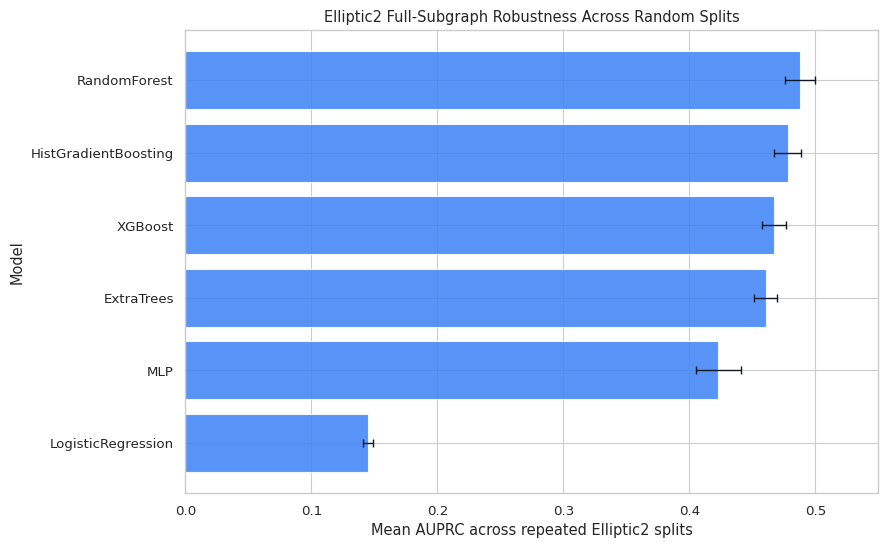

,model,n_splits,accuracy_mean,accuracy_std,accuracy_ci_lower_95,accuracy_ci_upper_95,precision_mean,precision_std,precision_ci_lower_95,precision_ci_upper_95,...,brier_ci_lower_95,brier_ci_upper_95,precision_at_k_mean,precision_at_k_std,precision_at_k_ci_lower_95,precision_at_k_ci_upper_95,recall_at_k_mean,recall_at_k_std,recall_at_k_ci_lower_95,recall_at_k_ci_upper_95
0,Elliptic2_RandomForest,5,0.981929,0.000336,0.981634,0.982223,0.907675,0.021991,0.888400,0.926951,...,0.015472,0.015855,0.273304,0.009329,0.265127,0.281481,0.601928,0.020546,0.583919,0.619937
1,Elliptic2_HistGradientBoosting,5,0.868312,0.005091,0.863849,0.872775,0.127467,0.004954,0.123124,0.131809,...,0.081237,0.084737,0.275711,0.008718,0.268069,0.283353,0.607229,0.019202,0.590398,0.624060
2,Elliptic2_XGBoost,5,0.854499,0.003438,0.851485,0.857513,0.117755,0.003017,0.115110,0.120400,...,0.091069,0.093913,0.271772,0.009865,0.263125,0.280420,0.598554,0.021727,0.579510,0.617599
3,Elliptic2_ExtraTrees,5,0.981611,0.000239,0.981402,0.981820,0.869886,0.023551,0.849243,0.890530,...,0.016418,0.016699,0.264333,0.011697,0.254080,0.274586,0.582169,0.025762,0.559588,0.604750
4,Elliptic2_MLP,5,0.981349,0.000416,0.980984,0.981713,0.751031,0.037117,0.718497,0.783566,...,0.016295,0.016871,0.249672,0.008382,0.242324,0.257019,0.549880,0.018462,0.533697,0.566062
5,Elliptic2_LogisticRegression,5,0.795304,0.002880,0.792780,0.797828,0.086140,0.001685,0.084664,0.087617,...,0.142556,0.145608,0.171554,0.008524,0.164082,0.179025,0.377831,0.018774,0.361376,0.394287


In [29]:
# ============================================================
# 14E. Elliptic2 Repeated-Split Robustness
# ============================================================

ell2_repeated_results = pd.DataFrame()
ell2_repeated_summary = pd.DataFrame()


def make_elliptic2_model_suite(seed, y_train):
    pos = max(1, int((y_train == 1).sum()))
    neg = max(1, int((y_train == 0).sum()))
    models = {
        "Elliptic2_LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", n_jobs=-1, random_state=seed),
        "Elliptic2_RandomForest": RandomForestClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=seed),
        "Elliptic2_ExtraTrees": ExtraTreesClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=seed),
        "Elliptic2_HistGradientBoosting": HistGradientBoostingClassifier(max_iter=180 if not SAMPLE_MODE else 80, learning_rate=0.06, random_state=seed),
        "Elliptic2_MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=120 if not SAMPLE_MODE else 60, early_stopping=True, random_state=seed),
    }
    if HAS_XGBOOST:
        models["Elliptic2_XGBoost"] = XGBClassifier(
            n_estimators=220 if not SAMPLE_MODE else 100,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=neg / pos,
            random_state=seed,
            n_jobs=-1,
        )
    return models


def make_stratified_70_15_15_masks(y, seed):
    idx = np.arange(len(y))
    s1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    tr_pos, temp_pos = next(s1.split(idx, y))
    tr_idx, temp_idx = idx[tr_pos], idx[temp_pos]
    s2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    va_pos, te_pos = next(s2.split(temp_idx, y[temp_idx]))
    va_idx, te_idx = temp_idx[va_pos], temp_idx[te_pos]
    tr = np.zeros(len(y), dtype=bool); tr[tr_idx] = True
    va = np.zeros(len(y), dtype=bool); va[va_idx] = True
    te = np.zeros(len(y), dtype=bool); te[te_idx] = True
    return tr, va, te


def summarize_repeated_splits(results, metric_cols):
    rows = []
    for model_name, g in results.groupby("model"):
        row = {"model": model_name, "n_splits": int(g["seed"].nunique())}
        for metric in metric_cols:
            vals = pd.to_numeric(g[metric], errors="coerce").dropna().to_numpy(dtype=float)
            row[f"{metric}_mean"] = float(vals.mean()) if len(vals) else np.nan
            row[f"{metric}_std"] = float(vals.std(ddof=1)) if len(vals) > 1 else 0.0
            if len(vals) > 1:
                half_width = 1.96 * vals.std(ddof=1) / math.sqrt(len(vals))
                row[f"{metric}_ci_lower_95"] = float(vals.mean() - half_width)
                row[f"{metric}_ci_upper_95"] = float(vals.mean() + half_width)
            else:
                row[f"{metric}_ci_lower_95"] = np.nan
                row[f"{metric}_ci_upper_95"] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).sort_values("auprc_mean", ascending=False).reset_index(drop=True)


if ell2_ready and RUN_ELLIPTIC2_REPEATED_SPLITS:
    y2_repeat = ell2_model["label"].to_numpy(dtype=int)
    X2_raw_repeat = ell2_model[ell2_feature_cols].to_numpy(dtype=np.float32)
    repeated_rows = []
    metric_cols_repeat = ["accuracy", "precision", "recall", "f1", "auroc", "auprc", "brier", "precision_at_k", "recall_at_k"]

    print("Running Elliptic2 repeated split robustness. Seeds:", ELLIPTIC2_REPEATED_SPLIT_SEEDS)
    for split_seed in ELLIPTIC2_REPEATED_SPLIT_SEEDS:
        tr_rep, va_rep, te_rep = make_stratified_70_15_15_masks(y2_repeat, split_seed)
        scaler_rep = StandardScaler()
        X_train_rep = scaler_rep.fit_transform(X2_raw_repeat[tr_rep]).astype(np.float32)
        X_val_rep = scaler_rep.transform(X2_raw_repeat[va_rep]).astype(np.float32)
        X_test_rep = scaler_rep.transform(X2_raw_repeat[te_rep]).astype(np.float32)
        y_train_rep = y2_repeat[tr_rep]
        y_val_rep = y2_repeat[va_rep]
        y_test_rep = y2_repeat[te_rep]
        sw_rep = compute_sample_weight(class_weight="balanced", y=y_train_rep)
        model_suite = make_elliptic2_model_suite(split_seed, y_train_rep)

        for model_name, model in model_suite.items():
            start = time.time()
            if model_name.endswith("HistGradientBoosting"):
                model.fit(X_train_rep, y_train_rep, sample_weight=sw_rep)
            elif model_name.endswith("XGBoost"):
                model.fit(X_train_rep, y_train_rep, eval_set=[(X_val_rep, y_val_rep)], verbose=False)
            else:
                model.fit(X_train_rep, y_train_rep)
            seconds = time.time() - start
            prob = model.predict_proba(X_test_rep)[:, 1]
            repeated_rows.append({
                "seed": split_seed,
                "model": model_name,
                "n_train": int(tr_rep.sum()),
                "n_validation": int(va_rep.sum()),
                "n_test": int(te_rep.sum()),
                "test_positive_rate": float(y_test_rep.mean()),
                "train_seconds": seconds,
                **compute_metrics(y_test_rep, prob, k_frac=PRECISION_RECALL_AT_K_FRAC),
            })
            print(f"seed={split_seed} {model_name}: AUPRC={safe_average_precision(y_test_rep, prob):.4f}, AUROC={safe_roc_auc(y_test_rep, prob):.4f}")
        gc.collect()

    ell2_repeated_results = pd.DataFrame(repeated_rows)
    ell2_repeated_summary = summarize_repeated_splits(ell2_repeated_results, metric_cols_repeat)
    save_table(ell2_repeated_results, "table_28_elliptic2_repeated_split_results.csv")
    save_table(ell2_repeated_summary, "table_29_elliptic2_repeated_split_summary.csv")

    plt.figure(figsize=(9, 5.6))
    plot_df = ell2_repeated_summary.sort_values("auprc_mean", ascending=True).copy()
    y_pos = np.arange(len(plot_df))
    plt.barh(y_pos, plot_df["auprc_mean"], color="#3B82F6", alpha=0.85)
    xerr = np.vstack([
        plot_df["auprc_mean"] - plot_df["auprc_ci_lower_95"],
        plot_df["auprc_ci_upper_95"] - plot_df["auprc_mean"],
    ])
    plt.errorbar(plot_df["auprc_mean"], y_pos, xerr=xerr, fmt="none", ecolor="#111827", capsize=3, linewidth=1)
    plt.yticks(y_pos, plot_df["model"].str.replace("Elliptic2_", "", regex=False))
    plt.xlabel("Mean AUPRC across repeated Elliptic2 splits")
    plt.ylabel("Model")
    plt.title("Elliptic2 Full-Subgraph Robustness Across Random Splits")
    plt.xlim(0, max(0.55, float(plot_df["auprc_ci_upper_95"].max()) + 0.03))
    save_figure("fig_12_elliptic2_repeated_split_auprc.png")
    display(ell2_repeated_summary)
else:
    print("Elliptic2 repeated-split robustness skipped. Check ell2_ready and RUN_ELLIPTIC2_REPEATED_SPLITS.")


In [30]:
# ============================================================
# 14F. Cross-Benchmark Synthesis: Elliptic vs Elliptic2
# ============================================================

if ell2_ready and len(ell2_performance_wide) > 0:
    elliptic_rank = pd.DataFrame([
        {"model": name, "benchmark": "Elliptic_transaction_node", "family": pred.get("family"), **compute_metrics(y_test, pred["test_prob"], k_frac=PRECISION_RECALL_AT_K_FRAC)}
        for name, pred in model_predictions.items()
    ]).sort_values("auprc", ascending=False)
    best_elliptic = elliptic_rank.head(1).copy()
    best_elliptic2 = ell2_performance_wide.head(1).copy()
    best_elliptic2["benchmark"] = "Elliptic2_subgraph_external"
    best_elliptic2["family"] = "subgraph_background_feature_external"

    common_cols = ["benchmark", "model", "family", "accuracy", "precision", "recall", "f1", "auroc", "auprc", "brier", "precision_at_k", "recall_at_k"]
    synthesis = pd.concat([
        best_elliptic[common_cols],
        best_elliptic2[common_cols],
    ], ignore_index=True)

    interpretation = pd.DataFrame([
        {
            "finding": "Internal Elliptic best model",
            "evidence": f"{best_elliptic.iloc[0]['model']} achieved AUPRC={best_elliptic.iloc[0]['auprc']:.3f}.",
            "paper_implication": "Use Elliptic as transaction-level internal benchmark.",
        },
        {
            "finding": "External Elliptic2 best model",
            "evidence": f"{best_elliptic2.iloc[0]['model']} achieved AUPRC={best_elliptic2.iloc[0]['auprc']:.3f}.",
            "paper_implication": "Use Elliptic2 as subgraph-level external validation with background-node feature aggregation; do not claim direct feature-space transfer.",
        },
        {
            "finding": "Cross-benchmark conclusion",
            "evidence": "Elliptic and Elliptic2 use different prediction units: transaction nodes vs labeled subgraphs.",
            "paper_implication": "Frame the paper as cross-benchmark evidence about evaluation design and laundering-shape modeling, not as one model transferred unchanged across datasets.",
        },
    ])
    save_table(synthesis, "table_26_cross_benchmark_best_models.csv")
    save_table(interpretation, "table_27_cross_benchmark_interpretation.csv")
    display(synthesis)
    display(interpretation)
else:
    print("Cross-benchmark synthesis skipped because Elliptic2 external results are unavailable.")

Saved table: /kaggle/working/tables/table_26_cross_benchmark_best_models.csv
Saved table: /kaggle/working/tables/table_27_cross_benchmark_interpretation.csv


,benchmark,model,family,accuracy,precision,recall,f1,auroc,auprc,brier,precision_at_k,recall_at_k
0,Elliptic_transaction_node,Extra Trees,tabular_ml,0.973872,0.923445,0.473039,0.625608,0.869470,0.569896,0.028745,0.458239,0.497549
1,Elliptic2_subgraph_external,Elliptic2_RandomForest,subgraph_background_feature_external,0.981885,0.928571,0.219277,0.354776,0.922606,0.494042,0.015623,0.270241,0.595181


,finding,evidence,paper_implication
0,Internal Elliptic best model,Extra Trees achieved AUPRC=0.570.,Use Elliptic as transaction-level internal ben...
1,External Elliptic2 best model,Elliptic2_RandomForest achieved AUPRC=0.494.,Use Elliptic2 as subgraph-level external valid...
2,Cross-benchmark conclusion,Elliptic and Elliptic2 use different predictio...,Frame the paper as cross-benchmark evidence ab...


## Robustness: Random Split Benchmark

This random split is not the main research design. It shows whether randomly shuffled evaluation overstates model performance relative to temporal testing.

In [31]:
# ============================================================
# 15. Random Split Robustness
# ============================================================

labeled_idx = np.where(y_all >= 0)[0]
y_labeled = y_all[labeled_idx]

s1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_SEED)
tr_pos, temp_pos = next(s1.split(labeled_idx, y_labeled))
tr_idx, temp_idx = labeled_idx[tr_pos], labeled_idx[temp_pos]
s2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=RANDOM_SEED)
val_pos, te_pos = next(s2.split(temp_idx, y_all[temp_idx]))
val_idx, te_idx = temp_idx[val_pos], temp_idx[te_pos]

scaler_r = StandardScaler()
Xr_train = scaler_r.fit_transform(X_all[tr_idx]).astype(np.float32)
Xr_val = scaler_r.transform(X_all[val_idx]).astype(np.float32)
Xr_test = scaler_r.transform(X_all[te_idx]).astype(np.float32)
yr_train, yr_val, yr_test = y_all[tr_idx], y_all[val_idx], y_all[te_idx]
sw_r = compute_sample_weight(class_weight="balanced", y=yr_train)

robust_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", solver="lbfgs", n_jobs=-1, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_SEED),
    "Extra Trees": ExtraTreesClassifier(n_estimators=TREE_ESTIMATORS, min_samples_leaf=2, class_weight="balanced", n_jobs=-1, random_state=RANDOM_SEED),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=120 if SAMPLE_MODE else 250, learning_rate=0.06, random_state=RANDOM_SEED),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=80 if SAMPLE_MODE else 160, early_stopping=True, random_state=RANDOM_SEED),
}
if HAS_XGBOOST:
    pos_r = max(1, int((yr_train == 1).sum()))
    neg_r = max(1, int((yr_train == 0).sum()))
    robust_models["XGBoost"] = XGBClassifier(
        n_estimators=160 if SAMPLE_MODE else 450,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=neg_r / pos_r,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

robust_tables = []
for name, model in robust_models.items():
    print("Random split training:", name)
    if name == "HistGradientBoosting":
        model.fit(Xr_train, yr_train, sample_weight=sw_r)
    elif name == "XGBoost":
        model.fit(Xr_train, yr_train, eval_set=[(Xr_val, yr_val)], verbose=False)
    else:
        model.fit(Xr_train, yr_train)
    prob = model.predict_proba(Xr_test)[:, 1]
    robust_tables.append(bootstrap_metric_ci(yr_test, prob, name, "random_test", BOOTSTRAP_RESAMPLES, RANDOM_SEED, PRECISION_RECALL_AT_K_FRAC))

robustness = pd.concat(robust_tables, ignore_index=True)
save_table(robustness, "table_10_random_split_robustness_with_ci.csv")
robustness.head()

Random split training: Logistic Regression
Random split training: Random Forest
Random split training: Extra Trees
Random split training: HistGradientBoosting
Random split training: MLP
Random split training: XGBoost
Saved table: /kaggle/working/tables/table_10_random_split_robustness_with_ci.csv


,model,split,metric,point_estimate,ci_lower_95,ci_upper_95,n_test,positive_rate,bootstrap_resamples,k_for_precision_recall_at_k
0,Logistic Regression,random_test,accuracy,0.877738,0.870580,0.885326,6985,0.097638,1000,350
1,Logistic Regression,random_test,precision,0.439522,0.413529,0.465595,6985,0.097638,1000,350
2,Logistic Regression,random_test,recall,0.916422,0.895583,0.936203,6985,0.097638,1000,350
3,Logistic Regression,random_test,f1,0.594106,0.568365,0.618521,6985,0.097638,1000,350
4,Logistic Regression,random_test,auroc,0.963536,0.957116,0.969522,6985,0.097638,1000,350


## Publication-Ready Synthesis Tables and Figures

This section converts the experimental outputs into manuscript-ready artifacts: a compact dataset/design table, explicit claims-and-evidence table, threats-to-validity table, manuscript blueprint, figure/table map, and two figures suitable for a Q1 empirical RegTech paper.


Saved table: /kaggle/working/tables/table_30_publication_dataset_design_summary.csv
Saved table: /kaggle/working/tables/table_31_publication_claims_and_evidence.csv
Saved table: /kaggle/working/tables/table_32_threats_to_validity_and_mitigation.csv
Saved table: /kaggle/working/tables/table_33_manuscript_section_blueprint.csv
Saved table: /kaggle/working/tables/table_34_publication_figure_table_map.csv
Saved figure: /kaggle/working/figures/fig_13_research_design_pipeline.png


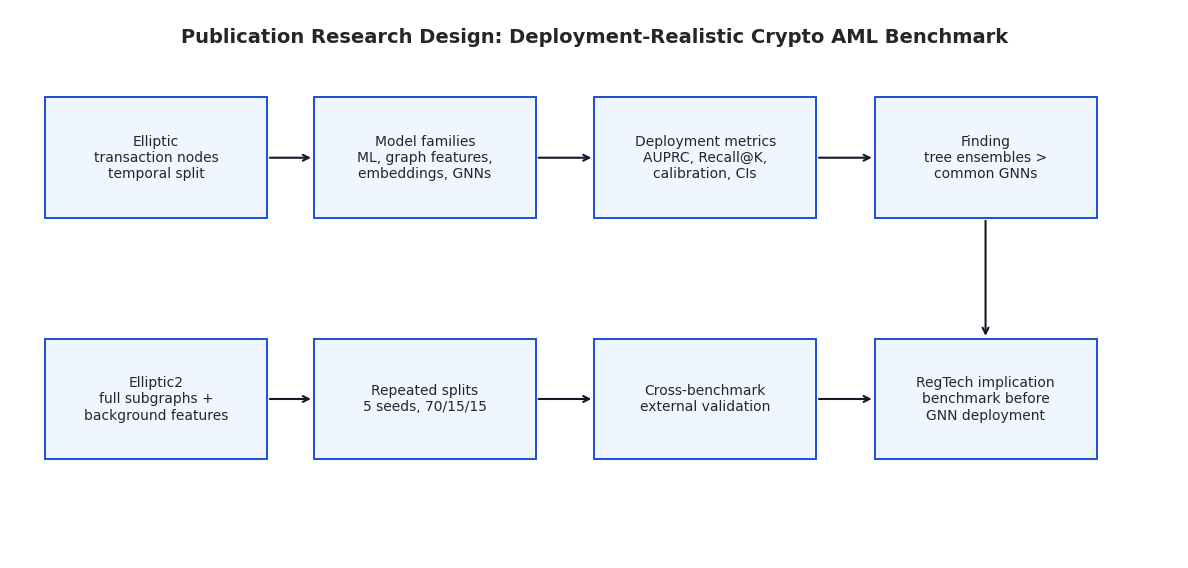

Saved figure: /kaggle/working/figures/fig_14_cross_benchmark_summary.png


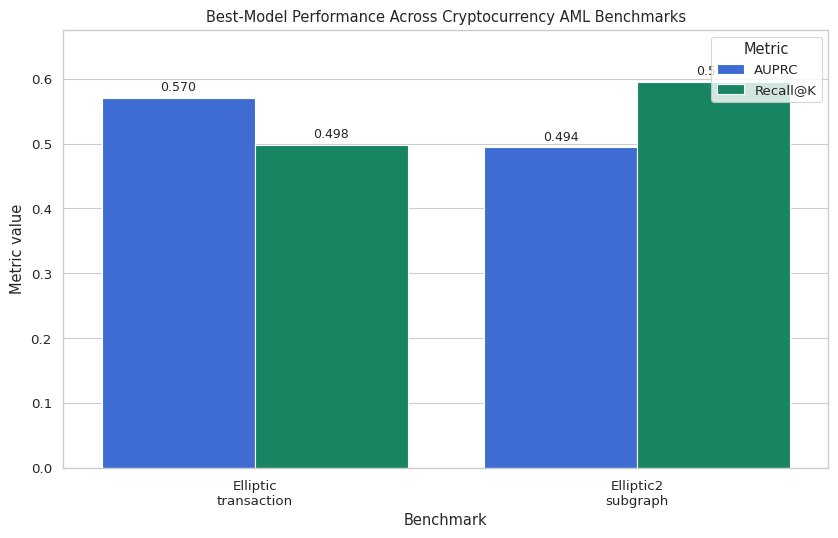

,component,unit_of_prediction,n_observations,n_positive,positive_rate,split_design,primary_metrics
0,Elliptic transaction-level benchmark,Transaction node,46564,4545,0.097608,Temporal train/validation/test split,"AUPRC, AUROC, Recall@K, Precision@K, calibrati..."
1,Elliptic2 subgraph-level benchmark,Connected component / subgraph,121810,2763,0.022683,Full subgraph benchmark with repeated stratifi...,"AUPRC, AUROC, Recall@K, Precision@K, repeated-..."


,claim,primary_evidence,supporting_artifacts,recommended_manuscript_location
0,Strong tree ensembles are the most reliable tr...,"Extra Trees achieved AUPRC=0.570, AUROC=0.869,...","table_6, table_7, fig_4, fig_5, fig_6",Results: Main Elliptic temporal benchmark
1,Common GNNs underperform strong non-GNN baseli...,Best non-graph minus best graph AUPRC gap=0.25...,"table_16b, table_20, table_21, table_18",Results: Graph AI comparison and statistical t...
2,The finding is not limited to Elliptic; full E...,"Full Elliptic2 uses 121,810 subgraphs and back...","table_24, table_25, table_28, table_29, fig_10...",Results: Elliptic2 cross-benchmark validation
3,Accuracy alone is inappropriate for AML model ...,Elliptic temporal test illicit rate=0.046; Ell...,"table_5, table_13, table_14, fig_1, fig_7",Discussion: Deployment and compliance implicat...


,threat,risk_to_claims,mitigation_in_study,paper_section
0,Anonymized features limit economic interpretab...,Feature-level causal claims cannot be made.,"Interpretation focuses on model families, vali...",Limitations
1,Elliptic and Elliptic2 use different predictio...,Direct model-transfer claims would be overstated.,The paper frames Elliptic2 as cross-benchmark ...,Data and Discussion
2,Labels are partially observed and unknown node...,Supervised metrics may understate or overstate...,Unknown labels are excluded from supervised ev...,Data Processing and Ethics
3,GNN implementation is lightweight and Kaggle-f...,A specialized temporal or heterogeneous GNN ma...,The paper limits claims to common reproducible...,Limitations and Future Work
4,AML deployment involves human review and insti...,Risk scores could be misused as proof of wrong...,The paper treats predictions as triage signals...,Practical Implications and Ethics


In [32]:
# ============================================================
# 16. Publication-Ready Synthesis Tables and Figures
# ============================================================

best_main = performance_wide.sort_values("auprc", ascending=False).iloc[0]
best_graph_pub = ranking[ranking["family"] == "graph_ai"].sort_values("auprc", ascending=False).head(1)
best_strict_graph_pub = ranking[ranking["family"] == "strict_temporal_graph_ai"].sort_values("auprc", ascending=False).head(1)
best_ell2_pub = ell2_performance_wide.sort_values("auprc", ascending=False).iloc[0] if len(ell2_performance_wide) else None
best_ell2_repeat_pub = ell2_repeated_summary.sort_values("auprc_mean", ascending=False).head(1) if len(ell2_repeated_summary) else pd.DataFrame()

publication_dataset_summary = pd.DataFrame([
    {
        "component": "Elliptic transaction-level benchmark",
        "unit_of_prediction": "Transaction node",
        "n_observations": int((nodes["label"] >= 0).sum()),
        "n_positive": int((nodes["label"] == 1).sum()),
        "positive_rate": float((nodes.loc[nodes["label"] >= 0, "label"] == 1).mean()),
        "split_design": "Temporal train/validation/test split",
        "primary_metrics": "AUPRC, AUROC, Recall@K, Precision@K, calibration, operating points",
    },
    {
        "component": "Elliptic2 subgraph-level benchmark",
        "unit_of_prediction": "Connected component / subgraph",
        "n_observations": int(len(ell2_model)) if ell2_ready else 0,
        "n_positive": int(ell2_model["label"].sum()) if ell2_ready else 0,
        "positive_rate": float(ell2_model["label"].mean()) if ell2_ready else np.nan,
        "split_design": "Full subgraph benchmark with repeated stratified 70/15/15 splits",
        "primary_metrics": "AUPRC, AUROC, Recall@K, Precision@K, repeated-split stability",
    },
])
save_table(publication_dataset_summary, "table_30_publication_dataset_design_summary.csv")

claims_rows = [
    {
        "claim": "Strong tree ensembles are the most reliable transaction-level AML detectors under temporal validation.",
        "primary_evidence": f"{best_main['model']} achieved AUPRC={best_main['auprc']:.3f}, AUROC={best_main['auroc']:.3f}, Recall@K={best_main['recall_at_k']:.3f} on the Elliptic temporal test set.",
        "supporting_artifacts": "table_6, table_7, fig_4, fig_5, fig_6",
        "recommended_manuscript_location": "Results: Main Elliptic temporal benchmark",
    },
    {
        "claim": "Common GNNs underperform strong non-GNN baselines in this deployment-realistic setting.",
        "primary_evidence": f"Best non-graph minus best graph AUPRC gap={float(diagnostic_notes.loc[diagnostic_notes['diagnostic']=='best_non_graph_minus_best_graph_auprc', 'value'].iloc[0]):.3f}; paired bootstrap Holm-corrected comparisons are reported in table_16b.",
        "supporting_artifacts": "table_16b, table_20, table_21, table_18",
        "recommended_manuscript_location": "Results: Graph AI comparison and statistical tests",
    },
    {
        "claim": "The finding is not limited to Elliptic; full Elliptic2 subgraph validation also favors tree ensembles.",
        "primary_evidence": "Full Elliptic2 uses 121,810 subgraphs and background-node features; best single-split and repeated-split models are reported in tables_24, 25, 28, and 29.",
        "supporting_artifacts": "table_24, table_25, table_28, table_29, fig_10, fig_11, fig_12",
        "recommended_manuscript_location": "Results: Elliptic2 cross-benchmark validation",
    },
    {
        "claim": "Accuracy alone is inappropriate for AML model selection because illicit cases are rare.",
        "primary_evidence": f"Elliptic temporal test illicit rate={float(y_test.mean()):.3f}; Elliptic2 positive rate={float(ell2_model['label'].mean()) if ell2_ready else np.nan:.3f}.",
        "supporting_artifacts": "table_5, table_13, table_14, fig_1, fig_7",
        "recommended_manuscript_location": "Discussion: Deployment and compliance implications",
    },
]
publication_claims = pd.DataFrame(claims_rows)
save_table(publication_claims, "table_31_publication_claims_and_evidence.csv")

threats_to_validity = pd.DataFrame([
    {
        "threat": "Anonymized features limit economic interpretability.",
        "risk_to_claims": "Feature-level causal claims cannot be made.",
        "mitigation_in_study": "Interpretation focuses on model families, validation design, operating metrics, and available graph diagnostics rather than causal feature semantics.",
        "paper_section": "Limitations",
    },
    {
        "threat": "Elliptic and Elliptic2 use different prediction units.",
        "risk_to_claims": "Direct model-transfer claims would be overstated.",
        "mitigation_in_study": "The paper frames Elliptic2 as cross-benchmark external validation, not direct feature-space transfer.",
        "paper_section": "Data and Discussion",
    },
    {
        "threat": "Labels are partially observed and unknown nodes are not clean negatives.",
        "risk_to_claims": "Supervised metrics may understate or overstate real-world AML performance.",
        "mitigation_in_study": "Unknown labels are excluded from supervised evaluation but retained for graph topology where appropriate.",
        "paper_section": "Data Processing and Ethics",
    },
    {
        "threat": "GNN implementation is lightweight and Kaggle-free-tier reproducible.",
        "risk_to_claims": "A specialized temporal or heterogeneous GNN may perform better.",
        "mitigation_in_study": "The paper limits claims to common reproducible GNNs and recommends stronger temporal/heterogeneous GNNs as future work.",
        "paper_section": "Limitations and Future Work",
    },
    {
        "threat": "AML deployment involves human review and institutional policies.",
        "risk_to_claims": "Risk scores could be misused as proof of wrongdoing.",
        "mitigation_in_study": "The paper treats predictions as triage signals and reports operating points, calibration, and false-positive tradeoffs.",
        "paper_section": "Practical Implications and Ethics",
    },
])
save_table(threats_to_validity, "table_32_threats_to_validity_and_mitigation.csv")

manuscript_blueprint = pd.DataFrame([
    {"section": "Abstract", "writing_goal": "State AML graph-AI promise, validation gap, two-benchmark design, and main finding that tree ensembles outperform common GNNs.", "key_artifacts": "table_26, table_31"},
    {"section": "Introduction", "writing_goal": "Motivate deployment-realistic AML evaluation and define RQ1-RQ4.", "key_artifacts": "fig_13, table_31"},
    {"section": "Literature Review", "writing_goal": "Position the paper across crypto AML, graph learning, RegTech, and evaluation leakage.", "key_artifacts": "narrative only"},
    {"section": "Data", "writing_goal": "Describe Elliptic and Elliptic2 units, labels, splits, and leakage controls.", "key_artifacts": "table_1, table_5, table_22, table_23, table_30"},
    {"section": "Methodology", "writing_goal": "Explain model families, feature sets, graph construction, confidence intervals, paired tests, repeated splits, and metrics.", "key_artifacts": "table_5f, table_16b, table_28, table_29"},
    {"section": "Results", "writing_goal": "Report main temporal benchmark, GNN underperformance, operating points, and full Elliptic2 validation.", "key_artifacts": "table_6, table_13, table_20, table_24, fig_4, fig_6, fig_12, fig_14"},
    {"section": "Discussion", "writing_goal": "Explain why graph structure does not guarantee GNN dominance and what compliance teams should do.", "key_artifacts": "table_21, table_31, table_32"},
    {"section": "Conclusion", "writing_goal": "Restate the cross-benchmark finding and deployment implication for RegTech model governance.", "key_artifacts": "table_31"},
])
save_table(manuscript_blueprint, "table_33_manuscript_section_blueprint.csv")

figure_table_map = pd.DataFrame([
    {"artifact": "fig_13_research_design_pipeline.png", "type": "figure", "paper_use": "Introduction / Methodology overview"},
    {"artifact": "fig_14_cross_benchmark_summary.png", "type": "figure", "paper_use": "Results summary"},
    {"artifact": "table_30_publication_dataset_design_summary.csv", "type": "table", "paper_use": "Data section"},
    {"artifact": "table_31_publication_claims_and_evidence.csv", "type": "table", "paper_use": "Discussion / contribution summary"},
    {"artifact": "table_32_threats_to_validity_and_mitigation.csv", "type": "table", "paper_use": "Limitations"},
    {"artifact": "table_33_manuscript_section_blueprint.csv", "type": "table", "paper_use": "Author planning / supplement"},
])
save_table(figure_table_map, "table_34_publication_figure_table_map.csv")

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.axis("off")
boxes = [
    (0.03, 0.62, "Elliptic\ntransaction nodes\ntemporal split"),
    (0.26, 0.62, "Model families\nML, graph features,\nembeddings, GNNs"),
    (0.50, 0.62, "Deployment metrics\nAUPRC, Recall@K,\ncalibration, CIs"),
    (0.74, 0.62, "Finding\ntree ensembles >\ncommon GNNs"),
    (0.03, 0.18, "Elliptic2\nfull subgraphs +\nbackground features"),
    (0.26, 0.18, "Repeated splits\n5 seeds, 70/15/15"),
    (0.50, 0.18, "Cross-benchmark\nexternal validation"),
    (0.74, 0.18, "RegTech implication\nbenchmark before\nGNN deployment"),
]
for x, y, label in boxes:
    rect = plt.Rectangle((x, y), 0.19, 0.22, transform=ax.transAxes, facecolor="#EFF6FF", edgecolor="#1D4ED8", linewidth=1.4)
    ax.add_patch(rect)
    ax.text(x + 0.095, y + 0.11, label, ha="center", va="center", fontsize=10, transform=ax.transAxes)
for y in [0.73, 0.29]:
    for x1, x2 in [(0.22, 0.26), (0.45, 0.50), (0.69, 0.74)]:
        ax.annotate("", xy=(x2, y), xytext=(x1, y), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", lw=1.5, color="#111827"))
ax.annotate("", xy=(0.835, 0.40), xytext=(0.835, 0.62), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", lw=1.5, color="#111827"))
ax.text(0.5, 0.95, "Publication Research Design: Deployment-Realistic Crypto AML Benchmark", ha="center", va="center", fontsize=14, fontweight="bold", transform=ax.transAxes)
save_figure("fig_13_research_design_pipeline.png")

if ell2_ready and len(ell2_performance_wide) > 0:
    summary_rows = [
        {"benchmark": "Elliptic\ntransaction", "metric": "AUPRC", "value": float(best_main["auprc"]), "model": best_main["model"]},
        {"benchmark": "Elliptic\ntransaction", "metric": "Recall@K", "value": float(best_main["recall_at_k"]), "model": best_main["model"]},
        {"benchmark": "Elliptic2\nsubgraph", "metric": "AUPRC", "value": float(best_ell2_pub["auprc"]), "model": best_ell2_pub["model"]},
        {"benchmark": "Elliptic2\nsubgraph", "metric": "Recall@K", "value": float(best_ell2_pub["recall_at_k"]), "model": best_ell2_pub["model"]},
    ]
    cross_plot = pd.DataFrame(summary_rows)
    plt.figure(figsize=(8.5, 5.5))
    sns.barplot(data=cross_plot, x="benchmark", y="value", hue="metric", palette=["#2563EB", "#059669"])
    plt.ylabel("Metric value")
    plt.xlabel("Benchmark")
    plt.title("Best-Model Performance Across Cryptocurrency AML Benchmarks")
    plt.ylim(0, max(0.65, cross_plot["value"].max() + 0.08))
    for container in plt.gca().containers:
        plt.bar_label(container, fmt="%.3f", fontsize=9, padding=3)
    plt.legend(title="Metric", loc="upper right")
    save_figure("fig_14_cross_benchmark_summary.png")

display(publication_dataset_summary)
display(publication_claims)
display(threats_to_validity)


In [33]:
# ============================================================
# 17. Variable Dictionary and Output Inventory
# ============================================================

var_rows = [
    {"variable": "txId", "description": "Anonymized Bitcoin transaction identifier."},
    {"variable": "time_step", "description": "Temporal slice in the Elliptic dataset."},
    {"variable": "class", "description": "Original class: 1 illicit, 2 licit, unknown unlabeled."},
    {"variable": "label", "description": "Binary target: 1 illicit, 0 licit, -1 unknown."},
    {"variable": "src", "description": "Source node index in the transaction graph."},
    {"variable": "dst", "description": "Destination node index in the transaction graph."},
    {"variable": "risk_score_best_model", "description": "Predicted illicit risk from the best model."},
]
for f in feature_cols:
    var_rows.append({"variable": f, "description": "Anonymized Elliptic transaction feature."})
variable_dictionary = pd.DataFrame(var_rows)
save_table(variable_dictionary, "table_11_variable_dictionary.csv")

inventory = []
for folder in [TABLE_DIR, FIG_DIR, DATA_OUT_DIR, MODEL_DIR]:
    for p in sorted(folder.glob("*")):
        inventory.append({"folder": str(folder), "file": p.name, "size_bytes": p.stat().st_size})
inventory = pd.DataFrame(inventory)
save_table(inventory, "table_12_output_inventory.csv")
inventory

Saved table: /kaggle/working/tables/table_11_variable_dictionary.csv
Saved table: /kaggle/working/tables/table_12_output_inventory.csv


,folder,file,size_bytes
0,/kaggle/working/tables,table_10_random_split_robustness_with_ci.csv,6661
1,/kaggle/working/tables,table_11_variable_dictionary.csv,8159
2,/kaggle/working/tables,table_13_aml_operating_points.csv,37900
3,/kaggle/working/tables,table_14_aml_operating_points_with_ci.csv,161561
4,/kaggle/working/tables,table_15_model_rankings_for_paired_tests.csv,2737
...,...,...,...
63,/kaggle/working/processed_data,predictions_main_test_set.csv,4941158
64,/kaggle/working/models,gatlite.pt,34713
65,/kaggle/working/models,gcn.pt,66357
66,/kaggle/working/models,graphsage.pt,130353


## How To Interpret the Results for the Paper

Use one narrative only: **a deployment-realistic benchmark showing that common graph neural networks do not automatically outperform strong tree ensembles for cryptocurrency AML under temporal and cross-benchmark validation.**

Do not frame the manuscript as a new-GNN paper. Frame it as a RegTech model-governance paper with three evidence pillars:

1. **Temporal validity:** performance is evaluated on later Elliptic time steps, not only random splits.
2. **External/cross-benchmark validity:** the full Elliptic2 subgraph benchmark tests whether findings remain plausible beyond one transaction-node dataset.
3. **Operational validity:** AUPRC, Recall@K, Precision@K, calibration, operating points, and corrected paired tests are prioritized over accuracy.

Primary reporting artifacts:

- Main temporal benchmark: `table_6_main_model_performance_with_ci.csv` and `table_7_main_model_performance_wide.csv`.
- Corrected paired tests: `table_16b_paired_bootstrap_model_comparisons_corrected.csv`.
- Operating points: `table_13_aml_operating_points.csv` and `table_14_aml_operating_points_with_ci.csv`.
- Elliptic2 full benchmark: `table_24_elliptic2_external_performance_with_ci.csv` and `table_25_elliptic2_external_performance_wide.csv`.
- Elliptic2 repeated splits: `table_28_elliptic2_repeated_split_results.csv` and `table_29_elliptic2_repeated_split_summary.csv`.
- Publication synthesis: `table_30` to `table_34`, `fig_13`, and `fig_14`.
